In [58]:
import numpy as np
import matplotlib.pyplot as plt
from load_dataset import loadDataSet
from mean_covariance import compute_mu_C, compute_C, vcol, vrow
from normalize import normalizeDataSet

filename = "dataset/trainData.txt"

numFeatures = 6

## Data Loading and normalization

In [59]:
features, labels = loadDataSet(filename, numFeatures)

print(f"features shape: {features.shape}\nLabels shape: {labels.shape}")

features shape: (6, 6000)
Labels shape: (6000,)


In [60]:
#Mean and Covariance
mu, C = compute_mu_C(features)
print(f"mu shape: {mu.shape}\nC shape: {C.shape}")
print(f"mu: {mu}\nC: {C}")

mu shape: (6, 1)
C shape: (6, 6)
mu: [[ 0.00170711]
 [ 0.00503903]
 [-0.00560753]
 [ 0.00109537]
 [-0.00700025]
 [ 0.00910515]]
C: [[ 1.00134304e+00  5.16755817e-03  1.76746375e-03  1.45268757e-02
   1.00066790e-02 -1.29591239e-02]
 [ 5.16755817e-03  9.98352699e-01 -1.58354137e-02 -4.40650280e-04
  -4.01307317e-03 -8.17687100e-04]
 [ 1.76746375e-03 -1.58354137e-02  1.00248180e+00 -4.37060381e-01
  -2.68600594e-02  6.34388503e-03]
 [ 1.45268757e-02 -4.40650280e-04 -4.37060381e-01  9.90293894e-01
   2.53357434e-02  8.26930215e-03]
 [ 1.00066790e-02 -4.01307317e-03 -2.68600594e-02  2.53357434e-02
   1.00119747e+00  8.75793087e-04]
 [-1.29591239e-02 -8.17687100e-04  6.34388503e-03  8.26930215e-03
   8.75793087e-04  9.97223742e-01]]


In [61]:
#Normalize the dataset
normalizedFeatures = normalizeDataSet(features, mu)
print(f"Normalized features shape: {normalizedFeatures.shape}")
#show all the 6 features for sample 0, before and after normalzation
print(f"features, sample0 before norm: {features[:, 0]}\nfeature, sample0 after norm: {normalizedFeatures[:, 0]}") 


Normalized features shape: (6, 6000)
features, sample0 before norm: [ 1.85284048 -0.16436898  1.09839078 -0.93073689 -1.0193342   1.16696309]
feature, sample0 after norm: [ 1.84989155 -0.16954771  1.1026309  -0.93638768 -1.01172838  1.15946855]


### Uni-variate Gaussian Models

In this section I will try to fit uni-variate Gaussian models to the different features of the different classes of the project
dataset. 
- For each class, for each component of the feature vector of that class, I compute the ML estimate
for the parameters of a 1D Gaussian distribution

In [62]:
import sys
ggm_path = './models/ggm'
if not ggm_path in sys.path:
    sys.path.append(ggm_path)

import logpdf_loglikelihood_GAU as logpdf_functions

In [63]:
print(f"Dataset shape: {normalizedFeatures.shape}")
print(f"M is {normalizedFeatures.shape[0]}")
print(f"N is {normalizedFeatures.shape[1]}")

Dataset shape: (6, 6000)
M is 6
N is 6000


Since the dataset has $M = 6$ dimensions, I will calculate the *log-pdf* of the **MVG** distibution, wich in the log-domain is written as:
$$
\log \mathcal{N}(x \mid \mu, \Sigma) =
- \frac{M}{2} \log 2\pi
- \frac{1}{2} \log |\Sigma|
- \frac{1}{2} (x - \mu)^T \Sigma^{-1} (x - \mu)
$$ 
where $\Sigma$ is the Covariance Matrix, $\mu$ is the mean. <br>
The ML estimate for the parameters of a Multivariate Gaussian distribution correspond to the empirical
dataset mean and the empirical dataset covariance, which are:
$$
\mu_{ML} = \frac{1}{N} \sum_{i=1}^{N} x_i , \quad 
\Sigma_{ML} = \frac{1}{N} \sum_{i=1}^{N} (x_i - \mu)(x_i - \mu)^T
$$

logpdf shape: (6000,)


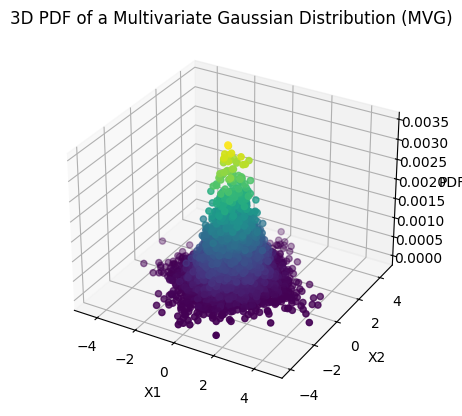

In [64]:
logpdf = logpdf_functions.logpdf_GAU_ND(normalizedFeatures, mu, C)
print(f"logpdf shape: {logpdf.shape}")

logpdf_functions.plotPdf3D(normalizedFeatures, logpdf)

In [65]:
normalizedFeatures.shape

(6, 6000)

In [66]:
normalizedFeatures[0:1, labels == 0].shape

(1, 2990)

In [67]:
#Compute log pdf for feature 0, class 0
feature0_class0 = normalizedFeatures[0, labels == 0]
C

array([[ 1.00134304e+00,  5.16755817e-03,  1.76746375e-03,
         1.45268757e-02,  1.00066790e-02, -1.29591239e-02],
       [ 5.16755817e-03,  9.98352699e-01, -1.58354137e-02,
        -4.40650280e-04, -4.01307317e-03, -8.17687100e-04],
       [ 1.76746375e-03, -1.58354137e-02,  1.00248180e+00,
        -4.37060381e-01, -2.68600594e-02,  6.34388503e-03],
       [ 1.45268757e-02, -4.40650280e-04, -4.37060381e-01,
         9.90293894e-01,  2.53357434e-02,  8.26930215e-03],
       [ 1.00066790e-02, -4.01307317e-03, -2.68600594e-02,
         2.53357434e-02,  1.00119747e+00,  8.75793087e-04],
       [-1.29591239e-02, -8.17687100e-04,  6.34388503e-03,
         8.26930215e-03,  8.75793087e-04,  9.97223742e-01]])

In [68]:
feature0_class0.shape

(2990,)

In [69]:
np.cov(feature0_class0, rowvar=False)

array(0.56900742)

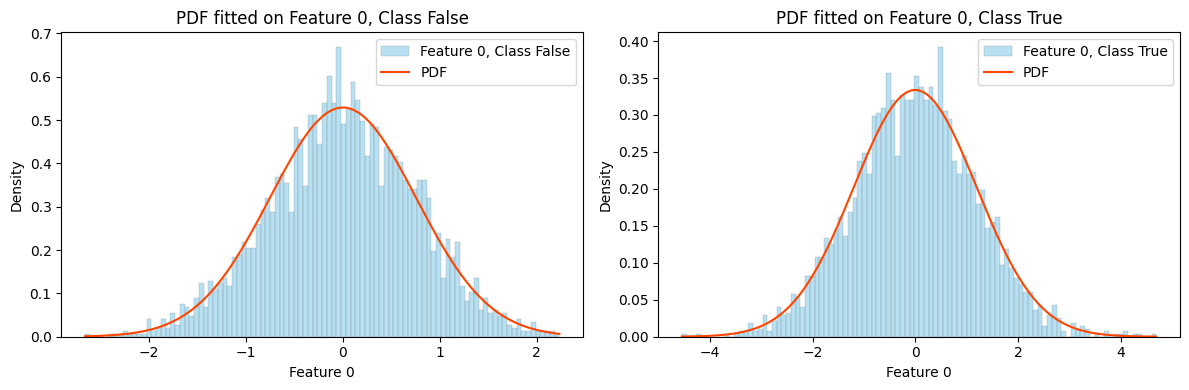

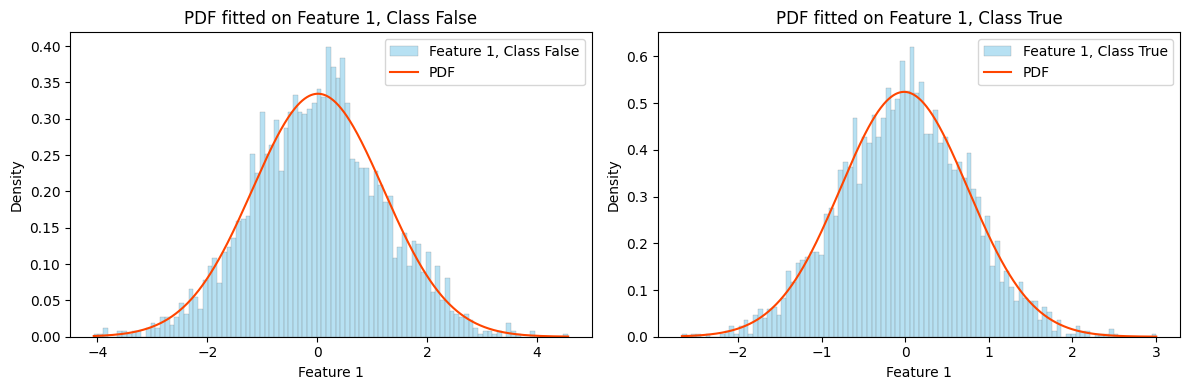

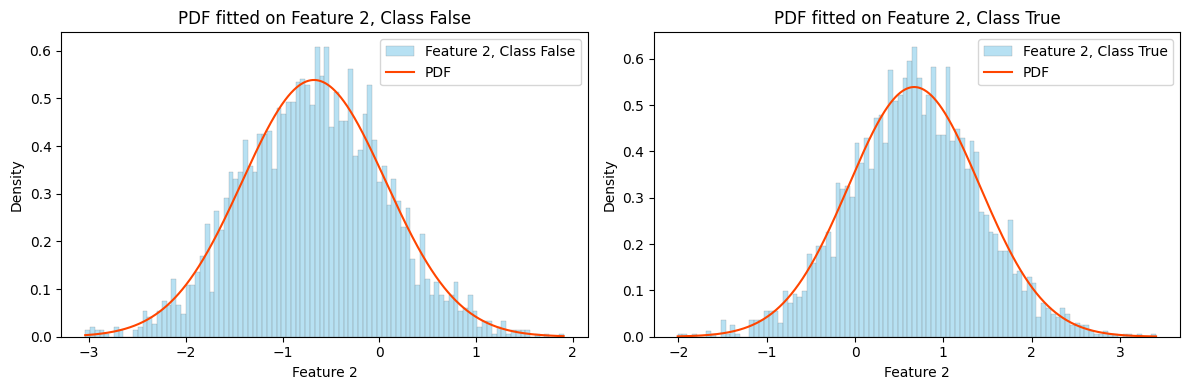

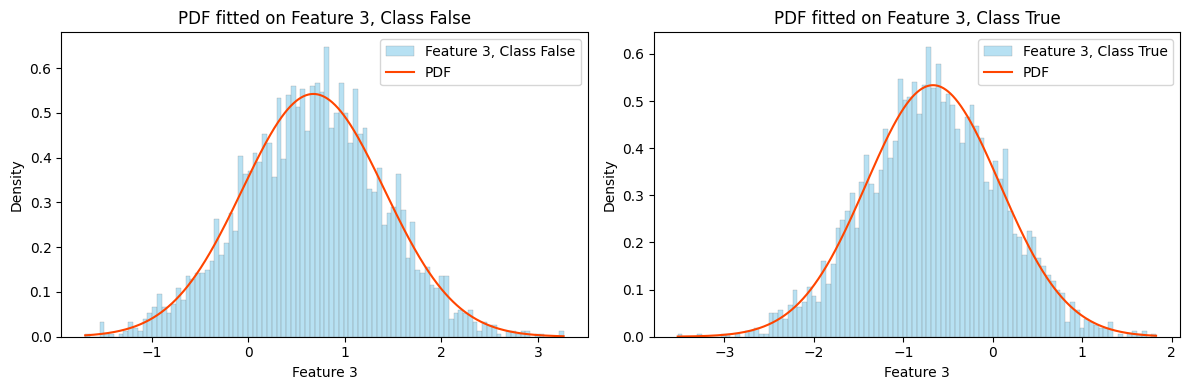

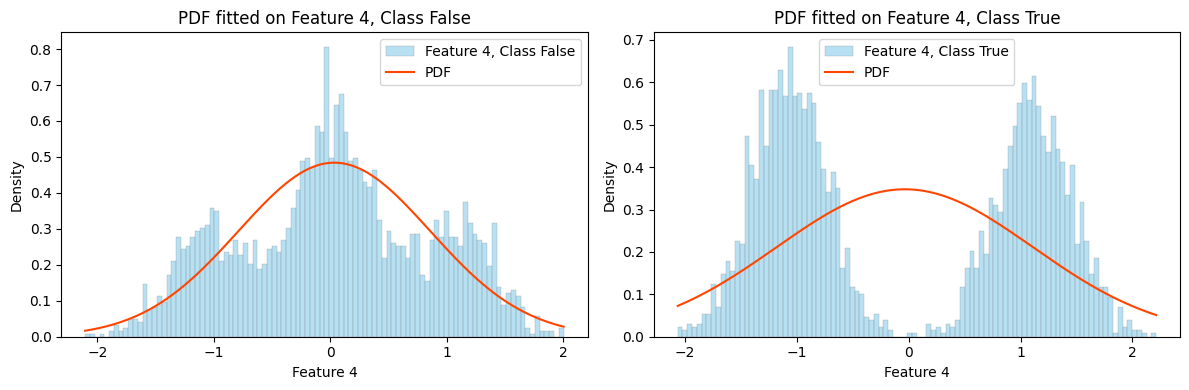

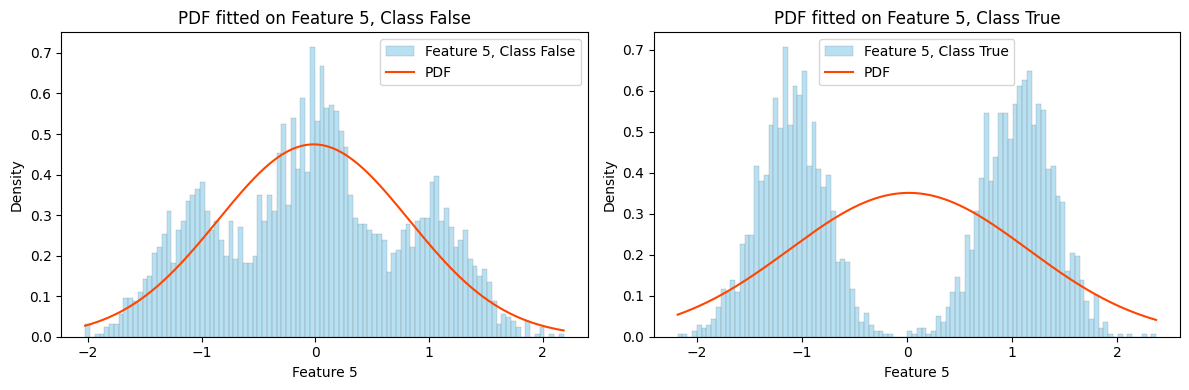

In [70]:
#For each feature, for each class, compute the log pdf
logpdf_feature_class = np.zeros((numFeatures, 2))

classLabels = {0: 'False', 1: 'True'}

for i in range(numFeatures):
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))     #create a figure with 2 subplots: one for class 0 and one for class 1

    for cls in classLabels.keys():

        D_i = normalizedFeatures[i:i+1, labels == cls]       #select feature i, class cls -> shape is (1, P) where P is the number of samples in class cls
        mu_i = D_i.mean()                                   #compute mean for feature i, class 0
        C_i = compute_C(D_i, mu_i)                          #compute covariance for feature i, class 0
        
        
        #Compute log pdf for feature i, class 0
        log_pdf_i_0 = logpdf_functions.logpdf_GAU_ND(D_i, mu_i, C_i)  #compute log pdf for feature i, class 0 

        axes[cls].hist(D_i.ravel(), bins=100, density=True, label=f'Feature {i}, Class {classLabels[cls]}', color='skyblue', alpha=0.6, edgecolor='grey', linewidth = 0.3)  #plot histogram for feature i, class cls
        XPlot = np.linspace(D_i.min(), D_i.max(), 1000)
        axes[cls].plot(XPlot.ravel(), np.exp(logpdf_functions.logpdf_GAU_ND(vrow(XPlot), mu_i, C_i)), label='PDF', color='orangered')  #plot pdf for feature i, class cls
            
        axes[cls].set_title(f'PDF fitted on Feature {i}, Class {classLabels[cls]}')
        axes[cls].legend()
        axes[cls].set_xlabel(f'Feature {i}')
        axes[cls].set_ylabel('Density')
        logpdf_feature_class[i, cls] = log_pdf_i_0.mean()

    plt.tight_layout()
    plt.show()


   






As we can see from the charts, the Gaussian density can be fitted well on features $0, 1, 2, 3$ whereas if applied on features $4, 5$ it produces far worse results

## Generative Gaussian Models (gmm) application on the dataset
Now I'll try to fit some Generative Gaussian Models on the dataset, in order to test their goodness. <br>
First of all, let's split the dataset into a training part (*DTR, LTR*) and a validation/estimation part (*DVAL, LVAL*). In order to make the models comparable, I shall use the **same split** used when fitting PCA and LDA models:

In [71]:
preSplit = np.load("./split/split_data.npz")

DTR = preSplit["DTR"]
LTR = preSplit["LTR"]
DVAL = preSplit["DVAL"]
LVAL = preSplit["LVAL"]

print(f"DTR shape: {DTR.shape}\nLTR shape: {LTR.shape}\nDVAL shape: {DVAL.shape}\nLVAL shape: {LVAL.shape}")

DTR shape: (6, 4000)
LTR shape: (4000,)
DVAL shape: (6, 2000)
LVAL shape: (2000,)


### 1. MVG (Multivariate Gaussian) Classifier
First, let's import the model functions:

In [72]:
MVG_path = './models/ggm/MVG'
if not MVG_path in sys.path:
    sys.path.append(MVG_path)

import MVG

The optimal Bayes decision is to select for each test point the class with highest **posterior probability**: having class $c$ and $x_{t}$ as test point, we can thus write:
$$
c_{t}^{*} = argmax_{c} P (C_{t} = c \mid \mathbf{X}_t = \mathbf{x}_t) \rightarrow We \space assign \space x_{t} \space to \space the \space class \space having \space the \space highest \space Posterior \space probability
$$ 
We will assume that the samples are independent and identically distributed (*i.i.d.*) according to $(\mathbf{X}_t, C_{t}) ∼ (\mathbf{X}, C)$. <br>
Let $f_{X,C}$ be the joint density of $X, C$: we can
compute the joint likelihood for the hypothesized class $c$ for the observed test
sample $x_{t}$ as $f_{X,C}(x_{t}, c)$ and then use **Bayes rule** to compute the class posterior
probability:
$$
P(C_t = c \mid \mathbf{X}_t = \mathbf{x}_t) = \frac{f_{\mathbf{X},C}(\mathbf{x}_t, c)}{\sum_{c' \in C} f_{\mathbf{X},C}(\mathbf{x}_t, c')}
$$
We can factorize the joint density as:
$$
f_{\mathbf{X}_t, C_t}(\mathbf{x}_t, c) = f_{\mathbf{X} \mid C}(\mathbf{x}_t \mid c) P(c)
$$
Where:
- $f_{\mathbf{X} \mid C}(\mathbf{x}_t \mid c)$ is the class conditional distribution 
- $P(c)$ is called *Prior probabilty*: it's application-dependent and describes the probability of the class being $c$ **before** we observe $x_{t}$ 

In this specific case, we assume that our data, given the class, can be described by a **Gaussian distribution**:
$$
(\mathbf{X}_t \mid C_{t} = c) ∼ (\mathbf{X} \mid C = c) ∼ \mathcal{N}(\mathbf{µ_{c}}, \mathbf{Σ_{c}})
$$
If we knew $\mathbf{µ_{c}}$, $\mathbf{Σ_{c}}$ then we could compute the conditional this way;
$$
f_{\mathbf{X} \mid C}(\mathbf{x}_t \mid c) = \mathcal{N}(\mathbf{µ_{c}}, \mathbf{Σ_{c}})
$$
The problem is that we don't have **these parameters** $\theta = [(\mathbf{µ_{1}}, \mathbf{Σ_{1}}), . . . ,(\mathbf{µ_{k}}, \mathbf{Σ_{k}})] $, where $k$ is the number of different classes. <br>
However, since we have at our disposal a *labeled Dataset*, we can assume:
- Gaussian distribution for $\mathbf{X} \mid C$
- That, given the model parameters $\theta$, all the samples observations are *i.i.d* 

After (and only after) making these assumptions, we can plug in the **Maximum Likelihood Estimators** (*MLE*), which, for a **MVG** distribution, are the empirical mean and covariance matrix of each class. So, for each class $c$ we can compute the two estimators:
$$
\mu^{MLE}_{c} = \frac{1}{N_c} \sum_{i} x_{c,i}, \quad 
\Sigma^{MLE}_{c} = \frac{1}{N_c} \sum_{i} (x_{c,i} - \mu^*_c)(x_{c,i} - \mu^*_c)^T
$$
Where $x_{c,i}$ is the $i$-th sample of class $c$. <br>
The ML estimators are computed this way:

In [73]:
#Compute the ML estimators of a MVG distribtion, which are the empirical mean and covariance of the training data
ML_params = MVG.computeParams_ML(DTR, LTR)
mu_0 = ML_params[0][0] #mean for class 0 (false)
C_0 = ML_params[0][1]  #covariance for class 0 (false)
mu_1 = ML_params[1][0] #mean for class 1 (true)
C_1 = ML_params[1][1]  #covariance for class 1 (true)

print(f"mu_0 shape: {mu_0.shape}\nC_0 shape: {C_0.shape}\nmu_1 shape: {mu_1.shape}\nC_1 shape: {C_1.shape}")
print(f"mu_0: {mu_0}\nC_0: {C_0}\nmu_1: {mu_1}\nC_1: {C_1}")

mu_0 shape: (6, 1)
C_0 shape: (6, 6)
mu_1 shape: (6, 1)
C_1 shape: (6, 6)
mu_0: [[-0.00822607]
 [ 0.01103328]
 [-0.66765899]
 [ 0.68274212]
 [ 0.02264805]
 [-0.02242518]]
C_0: [[ 6.00150483e-01  5.15945586e-05  1.90225386e-02  1.93341302e-02
   1.27876967e-02 -1.34818497e-02]
 [ 5.15945586e-05  1.44961338e+00 -1.61273162e-02 -1.59468029e-02
  -2.64588919e-02  2.29647800e-02]
 [ 1.90225386e-02 -1.61273162e-02  5.63949294e-01 -1.85016190e-03
  -6.90176748e-03  1.68953781e-02]
 [ 1.93341302e-02 -1.59468029e-02 -1.85016190e-03  5.46923701e-01
   5.27423072e-03  1.36570964e-02]
 [ 1.27876967e-02 -2.64588919e-02 -6.90176748e-03  5.27423072e-03
   6.95235119e-01  1.58563881e-02]
 [-1.34818497e-02  2.29647800e-02  1.68953781e-02  1.36570964e-02
   1.58563881e-02  6.88430972e-01]]
mu_1: [[-0.00640784]
 [-0.01442804]
 [ 0.66074454]
 [-0.6633144 ]
 [-0.03687303]
 [ 0.01588177]]
C_1: [[ 1.44615303e+00 -1.47244999e-02  5.55947189e-03  1.58079320e-02
   1.94723815e-02 -1.76809619e-04]
 [-1.47244999e

As we have already discussed, working directly with densities is often problematic, due to numerical
issues. It’s useful to implement the whole procedure directly in terms of log-densities (if we need, we can
recover posterior probabilities at the end). <br>
Working in the *log-domain*, the three stages for computing the class posterior probabilities $P(c \mid \mathbf{x})$ are: <br>
*Stage 1*: For each sample we compute the log-likelihoods, so the class conditional log-probabilities as:
$$
\log f_{X|C} (x_t | c) = \log \mathcal{N} (x_t | \mu^{MLE}_c, \Sigma^{MLE}_c)
$$

**Beware**: model params were estimated with the ML approach using the *training samples*, whereas densities are computed using *estimation samples*! <br>
I can automate the process and compute a *Score Matrix* having for each row i the log-likelihood of class i and so $S[i, j]$ is the log-likelihood of the j-th sample given the i-th class:

In [74]:
#1. Compute the Score Matrix for each class
#   S[i, j] is the lok-likelihood of the i-th sample given the j-th class
#   Beware: the log-likelihoods are computed using the VALIDATION set, not the training set

S_LogLikelihoods_MVG = MVG.scoreMatrix_Pdf_GAU(DVAL, ML_params, useLog=True)

print(f"S_LogLikelihoods_MVG shape, computed from the Validation Set: {S_LogLikelihoods_MVG.shape}")

S_LogLikelihoods_MVG shape, computed from the Validation Set: (2, 2000)


So, to summarize the Score Matrix is structured as follows:
- at row $0$ it stores the log-likelihood $\log f_{X|C} (x_t | c) = \log \mathcal{N} (x_t | \mu^{MLE}_c, \Sigma^{MLE}_c)$ of class $C = 0$. It has 4000 columns since the training dataset has got 4000 samples. So, for each sample it stores the log-likelihood of class $C = 0$ computed for that sample.
- at row $1$ it stores the log-likelihood $\log f_{X|C} (x_t | c) = \log \mathcal{N} (x_t | \mu^{MLE}_c, \Sigma^{MLE}_c)$ of class $C = 1$. For each sample it stores the log-likelihood of class $C = 1$ computed for that sample.

*Step 2*: since we are trying to solve a **Binary** classification problem (i.e. discriminating among class *True* and *False*), we can thus compute, always in the *log-domain*, the **class posterior log-ratio**, which is the log of the ratio between the two Posteriors:
$$
\log \text{r}(x_{t}) = \log \frac{P (C_{t} = \text{True} = 1 \mid \mathbf{X}_t = \mathbf{x}_t)}{P (C_{t} = \text{False} = 0 \mid \mathbf{X}_t = \mathbf{x}_t)}
= \log \frac{f_{X|C}(x_t | 1) P(C= 1)}{f_{X|C}(x_t | 0) P(C=0)}
$$
In the log domain this is the sum of two terms:
$$
\log \text{r}(x_{t}) = \log \frac{f_{X|C}(x_t | 1)}{f_{X|C}(x_t | 0)} +
\log \frac{P(C= 1)}{P(C=0)}
$$
So, we can see that $\log \text{r}(x_{t})$ depends on the log of the ratio between the likelihoods of the two classes, commonly called **log-likelihoods ratio** - $\text{llr}(x_t)$ - plus the log of the priors of the two classes, commonly called **prior log-odds**, which is application dependent and does not depend on our dataset. <br>
The prior log-odds will be the **Threshold** to which compare the log-likelihood ratio and can be rewritten as:
$$
\text{Treshold} = \log \frac{P(C= 1)}{P(C=0)} = \log \frac{\pi}{1- \pi}
$$
where $\pi$ is the prior, application dependent, probability of observing class $1$. <br>
For the moment, we can assume **uniform** priors so: $\pi = P(C=1) = 1- \pi = P(C=0) = \frac{1}{2}$. <br>
Given this assumption, we can rewrite the Threshold as:
$$
\text{Treshold} = \log \frac{\pi}{1- \pi} = \log \frac{1/2}{1-1/2} = 0
$$
The log-likelihood ratio can also be rewritten using the logarithms properties as:
$$
\text{llr}(x_{t}) = \log f_{X|C}(x_t | 1) - \log f_{X|C}(x_t | 0) = \log \mathcal{N}(x_t | \mu_1^{MLE}, \Sigma_1^{MLE}) - \log \mathcal{N}(x_t | \mu_0^{MLE}, \Sigma_0^{MLE})
$$
To summarize, the classification rule used for the MVG Binary classifier is derived from the comparison between the log-likelihood ratio and the Threshold: 
$$
\text{llr}(x_{t}) = \log \mathcal{N}(x_t | \mu_1^{MLE}, \Sigma_1^{MLE}) - \log \mathcal{N}(x_t | \mu_0^{MLE}, \Sigma_0^{MLE}) \gtrless \text{Threshold} = 0 \rightarrow
\begin{cases}
\text{class 1 = True} \space \text{    if } \text{llr}(x_{t}) \geq  0 \\
\text{class 0 = False} \space \text{    if } \text{llr}(x_{t}) < 0
\end{cases}
$$
In order to choose the decision surface, so to which class assign based on the disequation, I have to remember that the $llr(x_{t})$ was computed having at the numerator the log-likelihhod for class $1$, and at the denominator the log-likelihood for class $0$, so I assign class $1$ if $\text{llr}(x_{t}) \geq  0$ and class $0$ otherwise. <br>
Geometrically, this means that the decision surface corresponds to the set of points $x_t$ where the two class-conditional densities are equal—i.e., where 
$f(x_t∣1)=f(x_t∣0)$. This surface acts as the boundary between the two regions of the feature space, each of which is assigned to one of the two classes based on which likelihood is higher. For MVG models, this decision surface is **quadratic** in general, and it partitions the space such that samples falling on one side are closer (in terms of *Mahalanobis* distance) to the class-$1$ distribution, while those on the other side are closer to the class-$0$ distribution.




The predictions are thus obtained by assigning label $1$ to samples whose log-likelihood ratio is greater or equal to 0,
and label $0$ to the other samples:

In [75]:
#Then we compute the 1-D array of the log-likelihood ratios
#In the log-domain, we just need to subtract the log-likelihoods of the two classes
llr_MVG = S_LogLikelihoods_MVG[1, :] - S_LogLikelihoods_MVG[0, :]
print(f"llr Shape: {llr_MVG.shape}")

llr Shape: (2000,)


In [76]:
#Classification rule: assign samples whose llr_MVG >= 0 to class 2 and samples whose llr_MVG < 0 to class 1
PVAL_bin_MVG = np.where(llr_MVG >= 0, 1, 0) #assign samples whose llr_MVG >= 0 to class 2 and samples whose llr_MVG < 0 to class 1
print(f"Predictions shape: {PVAL_bin_MVG.shape}")
print(f"First 10 Predictions: {PVAL_bin_MVG[:10]}")

Predictions shape: (2000,)
First 10 Predictions: [0 0 1 0 0 1 0 0 0 0]


In [77]:
LVAL

array([0, 0, 1, ..., 0, 0, 0], shape=(2000,), dtype=int16)

We can now compute the statistics to analyze the goodness of the model: <br>
Error Rate for Binary MVG Classifier:


In [78]:
error_count_bin_MVG = np.count_nonzero(PVAL_bin_MVG != LVAL)
print(f"Number of wrong predictions: {error_count_bin_MVG}")
error_rate_bin_MVG = np.mean(PVAL_bin_MVG != LVAL)
print(f"Error Rate: {error_rate_bin_MVG:.2%}")

Number of wrong predictions: 140
Error Rate: 7.00%


In [79]:
DVAL.shape, LVAL.shape

((6, 2000), (2000,))

Accuracy, Precision, Recall, F-1 Score for the Binary MVG Classifier:

In [80]:
from sklearn.metrics import classification_report
print(classification_report(LVAL, PVAL_bin_MVG, digits=3))

              precision    recall  f1-score   support

           0      0.925     0.934     0.930       992
           1      0.935     0.926     0.930      1008

    accuracy                          0.930      2000
   macro avg      0.930     0.930     0.930      2000
weighted avg      0.930     0.930     0.930      2000



In [81]:
DVAL.reshape((DVAL.shape[1], DVAL.shape[0])).shape

(2000, 6)

### 2. Tied Covariance MVG Classifier
First, let's import the model functions:

In [82]:
TiedMVG_path = './models/ggm/MVG_TiedCov'
if not TiedMVG_path in sys.path:
    sys.path.append(TiedMVG_path)

import MVG_TiedCov as MVGTC

I now consider the Tied covariance version of the classifier, which assumes that the **covariance matrices of the different classes are tied**. This means that the noise is class-independent, so the
distribution of class samples around the class mean is the same for every class. <br>
The ML solution for the class means is the same as with the MVG model. The
ML solution for the covariance matrix is given by the empirical within-class covariance matrix ($S_{w}$):
$$
\Sigma^* = S_{w} = \frac{1}{N} \sum_c \sum_i (x_{c,i} - \mu_c^*) (x_{c,i} - \mu_c^*)^T
$$
It's important, again, to underline te fact that $\Sigma^* = S_{w}$ does **not** depend on the class $c$.
Remember that I have already computed within-class covariance matrices when I implemented LDA, but beware: this **happens just using the Maximum Likelihood estimators**, with other techniques this is not the same. <br>
To summarize, Tied Covariance MVG and LDA are the same when using MLE and assuming equal covariance matrices for the classes. The decision boundary will be the same, and both methods lead to the same discriminant function. As a matter of facts, LDA assumes that the data from each class follow a Gaussian distribution with the same covariance matrix but potentially different means, and the decision boundary is derived by comparing the log-likelihoods (which ultimately leads to a linear discriminant), so: 
-  In both cases, you're modeling the data as Gaussian distributions with different means and a shared covariance.
-  Both methods involve comparing the log-likelihood ratio (or discriminant function), which leads to the same decision boundary in the case of equal covariance matrices.

In [83]:
DTR.shape, LTR.shape, DVAL.shape, LVAL.shape

((6, 4000), (4000,), (6, 2000), (2000,))

In [84]:
np.unique(LTR)

array([0, 1], dtype=int16)

So, I can compute the estimators, plugging in the Tied Covariance assumption:

In [85]:
MVG_TiedCov_Params = MVGTC.computeParams_ML_TiedCov(DTR, LTR)
CTied = MVG_TiedCov_Params[0][1]                        #get the tied covariance matrix for all classes
print(f"Tied covariance matrix shape: {CTied.shape}")
print(f"Tied covariance matrix:\n{CTied}")

Tied covariance matrix shape: (6, 6)
Tied covariance matrix:
[[ 1.02357476 -0.00734384  0.01228427  0.01756927  0.01613338 -0.00682268]
 [-0.00734384  1.00151098 -0.01366731 -0.01252827 -0.0205547   0.01967182]
 [ 0.01228427 -0.01366731  0.56002077  0.01292037 -0.00533069  0.00113199]
 [ 0.01756927 -0.01252827  0.01292037  0.56109619 -0.00324564  0.02444591]
 [ 0.01613338 -0.0205547  -0.00533069 -0.00324564  1.01814643  0.01640816]
 [-0.00682268  0.01967182  0.00113199  0.02444591  0.01640816  0.99819912]]


Then I compute the log-likelihoods for class $0$ and class $1$:

In [86]:
#Then we can compute the log-likelihoods for class 0 and class 1 given the MLE parameters of the MVG distribution
#Beware: we use the VALIDATION data to compute the log-likelihoods, not the training data!
loglikelihood_0_TiedCov = logpdf_functions.logpdf_GAU_ND(DVAL, MVG_TiedCov_Params[0][0], CTied)
loglikelihood_1_TiedCov = logpdf_functions.logpdf_GAU_ND(DVAL, MVG_TiedCov_Params[1][0], CTied)
print(f"loglikelihood_0 Shape: {loglikelihood_0_TiedCov.shape}")
print(f"loglikelihood_1 Shape: {loglikelihood_1_TiedCov.shape}")

loglikelihood_0 Shape: (2000,)
loglikelihood_1 Shape: (2000,)


Then I compute the log-likelihood ratio $\text{llr}(x_t)$:

In [87]:
#Then we compute the 1-D array of the log-likelihood ratios
#In the log-domain, we just need to subtract the log-likelihoods of the two classes
llr_TiedCov = loglikelihood_1_TiedCov - loglikelihood_0_TiedCov
print(f"llr Shape: {llr_TiedCov.shape}")

llr Shape: (2000,)


The classification rule is the same as before:

In [88]:
#Classification rule: assign samples whose llr_MVG >= 0 to class 1 and samples whose llr_MVG < 0 to class 0
PVAL_bin_TiedCov = np.where(llr_TiedCov >= 0, 1, 0) #assign samples whose llr_MVG >= 0 to class 1 and samples whose llr_MVG < 0 to class 0
print(f"Predictions shape: {PVAL_bin_TiedCov.shape}")
print(f"First 10 Predictions: {PVAL_bin_TiedCov[:10]}")

Predictions shape: (2000,)
First 10 Predictions: [0 0 1 0 0 1 0 0 0 0]


Error Rate for Binary Tied Cov. MVG Classifier:

In [89]:
error_count_bin_TiedCov = np.count_nonzero(PVAL_bin_TiedCov != LVAL)
print(f"Number of wrong predictions: {error_count_bin_TiedCov}")
error_rate_bin_TiedCov = np.mean(PVAL_bin_TiedCov != LVAL)
print(f"Error Rate: {error_rate_bin_TiedCov:.2%}")

Number of wrong predictions: 186
Error Rate: 9.30%


In order to compare the result of the Tied Covariance MVG Classifier with the ones of the MVG Classifier we have to recall what "Tied Covariance assumption" means: it means we assume that each sample is distant to the respective class mean in the same way, for every class. In other words, forcing the model to operate using the same Covariance Matrix for every class means we force the model to generalize and assume **variances** (i.e. how samples are spread and distant from class means) and **correlations** (i.e. how the features are correlated between each other) are **exactly the same for every class**:
$$
\Sigma = 
\begin{pmatrix}
\sigma_{0}^2 & \sigma_{0,1} & \sigma_{0,2} & \sigma_{0,3} & \sigma_{0,4} & \sigma_{0,5} \\
\sigma_{0,1} & \sigma_{1}^2 & \sigma_{1,2} & \sigma_{1,3} & \sigma_{1,4} & \sigma_{1,5} \\
\sigma_{0,2} & \sigma_{1,2} & \sigma_{2}^2 & \sigma_{2,3} & \sigma_{2,4} & \sigma_{2,5} \\
\sigma_{0,3} & \sigma_{1,3} & \sigma_{2,3} & \sigma_{3}^2 & \sigma_{3,4} & \sigma_{3,5} \\
\sigma_{0,4} & \sigma_{1,4} & \sigma_{2,4} & \sigma_{3,4} & \sigma_{4}^2 & \sigma_{4,5} \\
\sigma_{0,5} & \sigma_{1,5} & \sigma_{2,5} & \sigma_{3,5} & \sigma_{4,5} & \sigma_{5}^2
\end{pmatrix}
$$
This may not be always the case and this assumption/approximation/generalization may introduce a *bias* in the model, which can achieve worse result in terms of Error Rate, compared to the MVG classifier which uses a distinct covariance matrix $\Sigma_c$ for every class $c$. <br>
To sum up: Tied Covariance models can capture correlations between features, but they may perform poorly when classes have significantly different distributions. On the other hand, if there is reason to believe that the covariance matrices should be similar across classes, the model can provide a more reliable estimate. <br>
**However, in this specific case, despite not showing a dramatic increase in Error Rate, it performes worse than the MVG model, which means it's better to work with difference Covariance Matrices per class!**



### 3. Naive Bayes MVG Classifier
First, let's import the model functions:

In [90]:
NBMVG_path = './models/ggm/Naive_Bayes'
if not NBMVG_path in sys.path:
    sys.path.append(NBMVG_path)

import Naive_Bayes as MVGNB

We now consider the Naive Bayes version of the classifier. As we have seen, the Naive Bayes version of
the MVG is simply a Gaussian classifier where the **covariance matrices are diagonal**. The MLE solution
for the mean parameters is the same. For the covariance matrices we diagonalize the MLE solution:
$$
\Sigma_c^{MLE, \space Naive Bayes} = \text{diag}(\Sigma_c^{MLE}) = \text{diag} \left[ \frac{1}{N_c} \sum_i (x_{c,i} - \mu_c^{MLE})(x_{c,i} - \mu_c^{MLE})^T \right]
$$
This originates from the assumption that the components of the feature vectors are (almost)
uncorrelated, so we can say that our covariance matrix would have all 0 elements
except on the diagonal. <br>
The Naive assumption, convined with
Gaussian assumption, models the distribution of each component as a univariate
Gaussian. We can again compute the ML estimates.

In [91]:
NB_params = MVGNB.computeParams_ML_NaiveBayesAssumption(DTR, LTR)

Then I compute the log-likelihoods for class $0$ and class $1$:

In [92]:
loglikelihood_0_NB = logpdf_functions.logpdf_GAU_ND(DVAL, NB_params[0][0], NB_params[0][1])
loglikelihood_1_NB = logpdf_functions.logpdf_GAU_ND(DVAL, NB_params[1][0], NB_params[1][1])

print(f"loglikelihood_0 Shape: {loglikelihood_0_NB.shape}")
print(f"loglikelihood_1 Shape: {loglikelihood_1_NB.shape}")

loglikelihood_0 Shape: (2000,)
loglikelihood_1 Shape: (2000,)


Then I compute the log-likelihood ratio $\text{llr}(x_t)$:

In [93]:
llr_NB = loglikelihood_1_NB - loglikelihood_0_NB

print(f"llr Shape: {llr_NB.shape}")

llr Shape: (2000,)


The classification rule is the same as before:

In [94]:
#Classification rule: assign samples whose llr_MVG >= 0 to class 1 and samples whose llr_MVG < 0 to class 0
PVAL_bin_NB = np.where(llr_NB >= 0, 1, 0) #assign samples whose llr_MVG >= 0 to class 1 and samples whose llr_MVG < 0 to class 0
print(f"Predictions shape: {PVAL_bin_NB.shape}")
print(f"First 10 Predictions: {PVAL_bin_NB[:10]}")

Predictions shape: (2000,)
First 10 Predictions: [0 0 1 0 0 1 0 0 0 0]


Error Rate for Binary Naive Bayes MVG Classifier:

In [95]:
error_count_bin_NB = np.count_nonzero(PVAL_bin_NB != LVAL)
print(f"Number of wrong predictions: {error_count_bin_NB}")
error_rate_bin_NB = np.mean(PVAL_bin_NB != LVAL)
print(f"Error Rate: {error_rate_bin_NB:.2%}")

Number of wrong predictions: 144
Error Rate: 7.20%


Comparison of the three Error Rates for the three Classifiers:

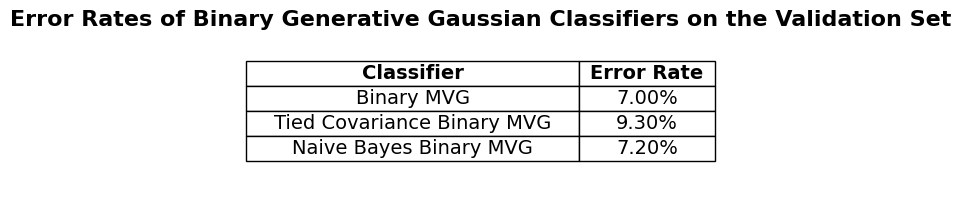

In [96]:
error_rates = [
    ("Binary MVG", error_rate_bin_MVG), 
    ("Tied Covariance Binary MVG", error_rate_bin_TiedCov),
    ("Naive Bayes Binary MVG", error_rate_bin_NB)
]

fig, ax = plt.subplots(figsize=(5, 2))
ax.axis('tight')
ax.axis('off')

table_data = [[name, f"{error:.2%}"] for name, error in error_rates]
table = ax.table(cellText=table_data, colLabels=["Classifier", "Error Rate"], loc="center")

#center text in the cells
for (i, j), cell in table.get_celld().items():
    if i == 0:
        cell.set_text_props(weight='bold')
    else:
        cell.set_text_props(ha='center', va='center')

table.auto_set_font_size(False)
table.set_fontsize(14)
table.auto_set_column_width([0, 1])
table.scale(1.5, 1.5)  # Adjust the scale for better visibility
plt.title("Error Rates of Binary Generative Gaussian Classifiers on the Validation Set", fontsize=16, weight='bold')
plt.savefig("./models/ggm/error_rates_binary.png", bbox_inches='tight', dpi=300) #save the figure with a resolution of 300 dpi
plt.show()

### 4. Extensive Models Comparison
Let’s now analyze the results in light of the characteristics of the features of the dataset. <br>
I start by showing the Covariance Matrices $\Sigma_{c1}$, $\Sigma_{c2}$ for each one of the two classes, they are basically the MLE found for the MVG Classifier:

In [97]:
import seaborn as sns

def showBinaryProblemCovs(cov0, cov1, text="Covariance"):
    """
    Show the covariance matrices of the two classes in a binary classification problem.

    Parameters:
    - cov0 (ndarray): Covariance matrix for class 0.
    - cov1 (ndarray): Covariance matrix for class 1.
    """


    fig, axs = plt.subplots(1, 2, figsize=(14, 6))

    fig.suptitle(f"{text} Matrices of the Two Classes", fontsize=16, weight='bold')
    sns.heatmap(cov0, annot=True, cmap='coolwarm', fmt='.5f', cbar=True, square=True, linewidths=0.5, ax=axs[0])
    axs[0].set_title(f"{text} Matrix - Class False (0)")
    axs[0].set_xlabel("Features")
    axs[0].set_ylabel("Features")

    sns.heatmap(cov1, annot=True, cmap='coolwarm', fmt='.5f', cbar=True, square=True, linewidths=0.5, ax=axs[1])
    axs[1].set_title(f"{text} Matrix - Class True (1)")
    axs[1].set_xlabel("Features")
    axs[1].set_ylabel("Features")


    plt.tight_layout()
    plt.subplots_adjust(top=0.85)  # Adjust the top to make room for the suptitle

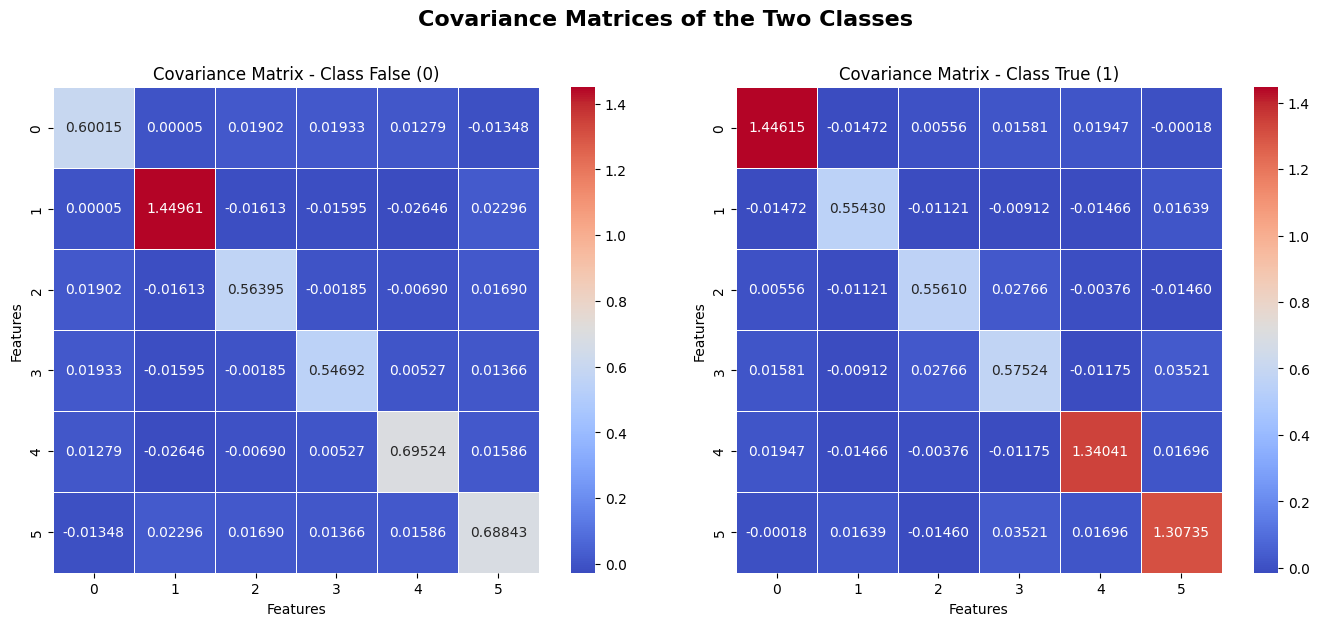

In [98]:
showBinaryProblemCovs(C_0, C_1)

The covariance matrices contain, on the diagonal, the variances for the different
features, whereas the elements outside of the diagonal are the co-variances of pairs of features. <br>
By comparing, for each class, the covariance of different feature pairs with the respective variances, we can understand the relative **strength of covariances with respect to variances**. The key points are:
- **Higher variances**: on the diagonal of both matrices we have higher elements, this means features variances are relatively higher and so, for each feature, samples have a bigger spread around their respective means. For class False (0), feature $1$ shows the highest variance and feature $2$, $3$ show the lowest one. For class True (1), features $0$, $4$, $5$ show the highest variances and features $1$, $2$ show the lowest ones.
- **Lower, almost zero, covariances**: covariances computed for pairs of features are almost zero, for every class. This means the dataset doesn't show a significative linear relation between the different features. <br>


In this case, the Covariance Matrices are approximately **diagonal**: this empicirally means that features are approximately linearly independent and using the Naive Bayes MVG model is a good idea, and this is confirmed by the fact its Error Rate is relatively low (7.2%).


I can compute the Pearson's Correlation Matrix to further visualize the strenght of variances against covariances:
$$
r_{ij} = \frac{\text{Cov}(X_i, X_j)}{\sigma_{X_i} \sigma_{X_j}}
$$
where $i$, $j$ are two distinct features

In [99]:
from correlation import computeCorrelation

#For each class compute the correlation matrix of the features having the Covariance matrix of the class

corr0 = computeCorrelation(C_0)
corr1 = computeCorrelation(C_1)
print(f"Correlation matrix for class 0 shape: {corr0.shape}")
print(f"Correlation matrix for class 1 shape: {corr1.shape}")


Correlation matrix for class 0 shape: (6, 6)
Correlation matrix for class 1 shape: (6, 6)


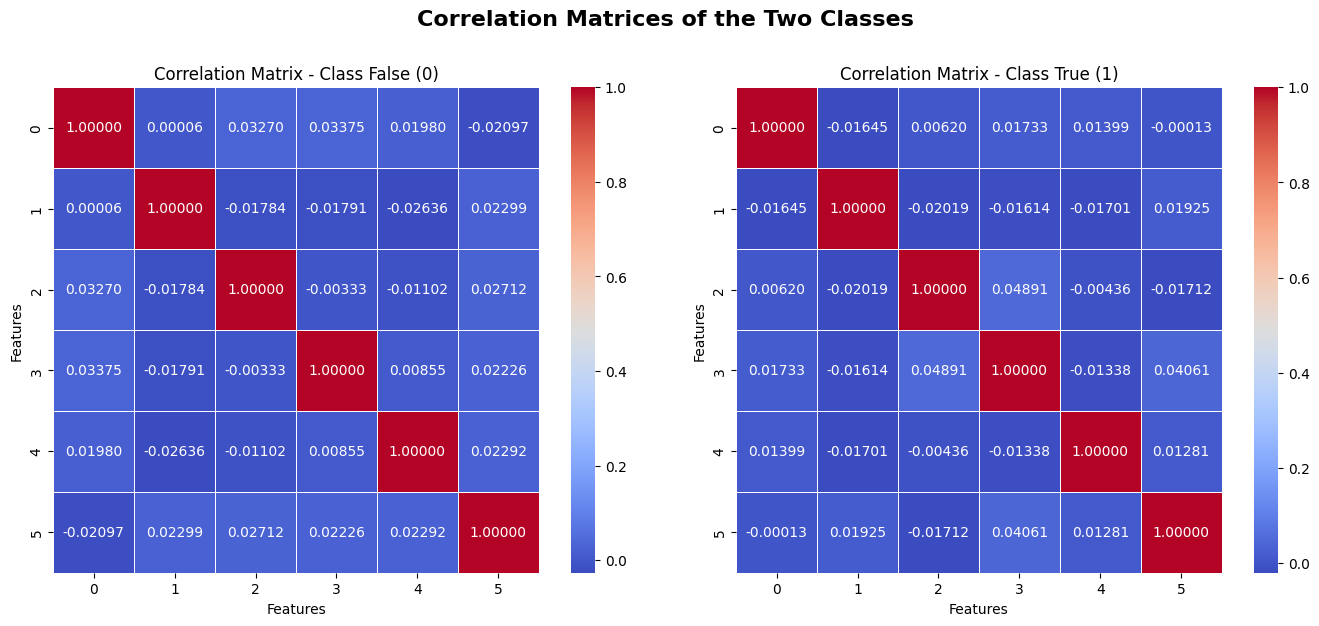

In [100]:
showBinaryProblemCovs(corr0, corr1, text="Correlation")

The correlation matrix has diagonal elements equal to 1, whereas out-of diagonal elements correspond to the correlation coefficients for all feature pairs, with $−1 ≤ r_{i, j} ≤ 1$.
When $r_{i, j} = 0$ the features $i$, $j$ are uncorrelated, whereas values close to $±1$ denote strong positive (+1) or negative (-1) correlation. <br>
By observing the Correlation Matrices we can tell that, for both classes, the features are **weakly** correlated! In many cases they're almost **uncorrelated**. <br>
This confirms the good results obtained by applying the **Naive Bayes** model: this model in facts is based on the assumption that features are independent. <br>
However, the crucial point is that **independece implies uncorrelation**, but the contrary is **not always true!** If features are independent, then they're surely uncorrelated and because of this the Naive Bayes Classifier performs well. <br>
So, I have to check first that the features are independent! As said before, the fact that Covariance Matrices are approximately diagonal empirically confirms this intuition. If I wanted to be more precise, I would have applied indepence tests as the *mutual information test*. <br>
Considering two discrete variables, $X$ and $Y$, the **mutual information** is computed as:
$$
I(X; Y) = \sum_{x \in \mathcal{X}} \sum_{y \in \mathcal{Y}} P(x, y) \log \left( \frac{P(x, y)}{P(x) P(y)} \right)
$$
Considering two continuous variables, $X$ and $Y$, the **mutual information** is computed as:
$$
I(X; Y) = \int_{\mathcal{X}} \int_{\mathcal{Y}} f(x, y) \log \left( \frac{f(x, y)}{f(x) f(y)} \right) dx\, dy
$$
Also note that:
1. $I(X; Y) \geq 0 $
2. $I(X; Y) = 0 \iff \text{X and Y are independent}$ <br>

Computing the integrals would be time consuming and more complex, so here it's better to discretize the features when testing for mutual information and approximate to the dicrete formula for $I(X; Y)$:

In [101]:
from sklearn.preprocessing import KBinsDiscretizer
from collections import Counter

def mutual_information_discrete(x, y, bins=10):
    # Discretize the continuous variables into bins
    # This lets us use the discrete formula for mutual information and don't compute the integrals
    kb = KBinsDiscretizer(n_bins=bins, encode='ordinal', strategy='uniform')
    x_binned = kb.fit_transform(x.reshape(-1, 1)).astype(int).flatten()
    y_binned = kb.fit_transform(y.reshape(-1, 1)).astype(int).flatten()

    N = len(x_binned)
    mi = 0.0

    joint_counts = Counter(zip(x_binned, y_binned))
    x_counts = Counter(x_binned)
    y_counts = Counter(y_binned)

    for (x_val, y_val), joint_count in joint_counts.items():
        p_xy = joint_count / N
        p_x = x_counts[x_val] / N
        p_y = y_counts[y_val] / N
        mi += p_xy * np.log(p_xy / (p_x * p_y + 1e-10) + 1e-10)

    return mi


#Compute the mutual information between each pair of features
def mutualInformationPairs(features):
    numFeatures = features.shape[0]

    for i in range(numFeatures):
        for j in range(i + 1, numFeatures):
            mi = mutual_information_discrete(features[i, :], features[j, :])
            print(f"Mutual Information between Feature {i} and Feature {j}: {mi:.5f}")


mutualInformationPairs(DTR)


Mutual Information between Feature 0 and Feature 1: 0.01188
Mutual Information between Feature 0 and Feature 2: 0.02480
Mutual Information between Feature 0 and Feature 3: 0.02127
Mutual Information between Feature 0 and Feature 4: 0.02038
Mutual Information between Feature 0 and Feature 5: 0.01876
Mutual Information between Feature 1 and Feature 2: 0.02751
Mutual Information between Feature 1 and Feature 3: 0.02997
Mutual Information between Feature 1 and Feature 4: 0.02055
Mutual Information between Feature 1 and Feature 5: 0.01977
Mutual Information between Feature 2 and Feature 3: 0.12092
Mutual Information between Feature 2 and Feature 4: 0.06832
Mutual Information between Feature 2 and Feature 5: 0.07458
Mutual Information between Feature 3 and Feature 4: 0.07313
Mutual Information between Feature 3 and Feature 5: 0.07500
Mutual Information between Feature 4 and Feature 5: 0.04393


All the discretized, approximated, mutual informations are **close to zero**. This means all the six features are **almost independent between each other**! <br>
This statistically confirms the empirical intuition given by looking at the Covariance Matrices that using a **Naive Bayes** Classifier produces good results!

### Testing the Gaussian Distribution assumption for each feature

Now, after the analysis of the variances and covariances, I have to test the accuracy of the **Gaussian Distribution** assumption.   
The Gaussian model assumes that features can be jointly modeled by Gaussian distributions. The goodness of the model is therefore strongly affected by the accuracy of this assumption. In the beginning I've already separately fitted a Gaussian density over each feature distribution (and this is exactly like performing a Naive Bayes fit, where each feature is considered distributed as a univariate Gaussian distribution). This lead to these results: the Gaussian assumption **holds strong** for features $0$, $1$, $2$, $3$, but it's **not accurate** for features $4$, $5$, whose densities are reported again here: <br> <br>
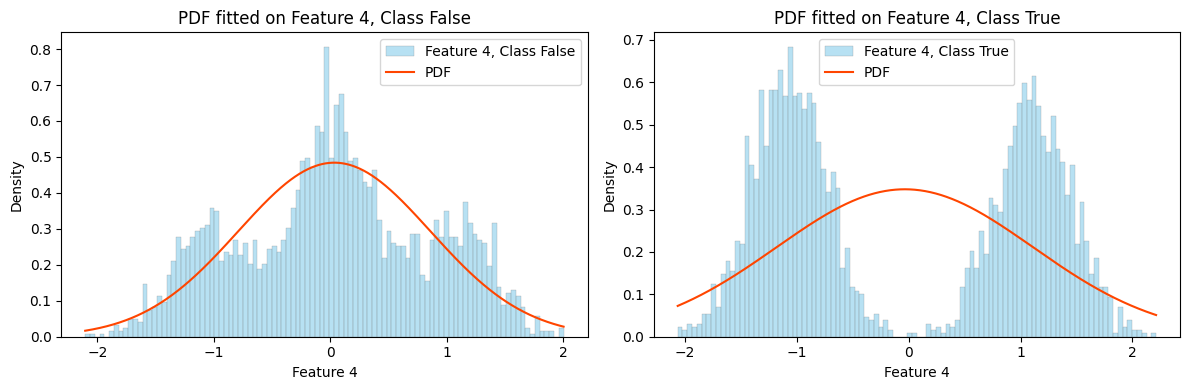 <br>
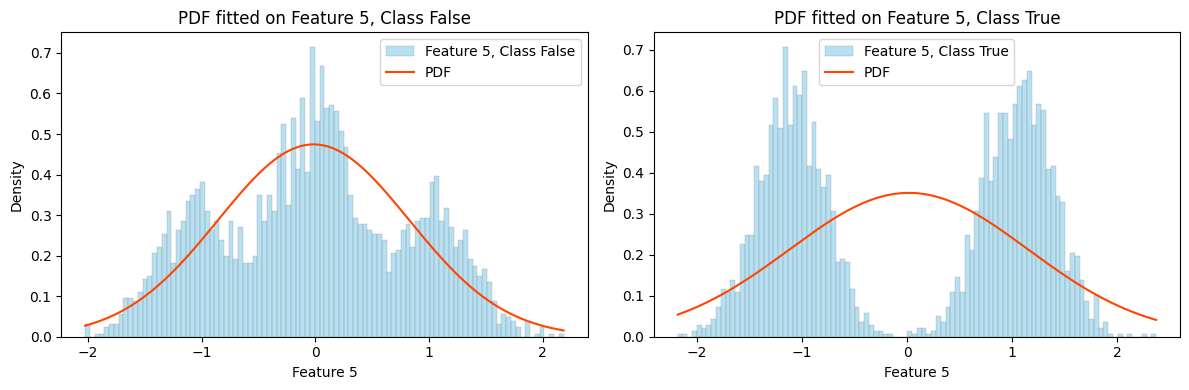 <br>
To check wether the last two features actually affect the three Classifiers in a **negative way**, I can repeat the analysis just on te first four features.



In [102]:
#discard the last 2 features from DTR, DVAL

DTR_4f = DTR[:-2, :]
DVAL_4f = DVAL[:-2, :]

print(f"DTR_4f shape: {DTR_4f.shape}\nDVAL_4f shape: {DVAL_4f.shape}")


DTR_4f shape: (4, 4000)
DVAL_4f shape: (4, 2000)


### 1. MVG Model fitted on just the four features

In [103]:
#Compute the ML estimators of a MVG distribtion, which are the empirical mean and covariance of the training data
ML_params_4f = MVG.computeParams_ML(DTR_4f, LTR)
mu_0_4f = ML_params_4f[0][0] #mean for class 0 (false)
C_0_4f = ML_params_4f[0][1]  #covariance for class 0 (false)
mu_1_4f = ML_params_4f[1][0] #mean for class 1 (true)
C_1_4f = ML_params_4f[1][1]  #covariance for class 1 (true)
print(f"mu_0_4f shape: {mu_0_4f.shape}\nC_0_4f shape: {C_0_4f.shape}\nmu_1_4f shape: {mu_1_4f.shape}\nC_1_4f shape: {C_1_4f.shape}")
print(f"mu_0_4f: {mu_0_4f}\nC_0_4f: {C_0_4f}\nmu_1_4f: {mu_1_4f}\nC_1_4f: {C_1_4f}")


mu_0_4f shape: (4, 1)
C_0_4f shape: (4, 4)
mu_1_4f shape: (4, 1)
C_1_4f shape: (4, 4)
mu_0_4f: [[-0.00822607]
 [ 0.01103328]
 [-0.66765899]
 [ 0.68274212]]
C_0_4f: [[ 6.00150483e-01  5.15945586e-05  1.90225386e-02  1.93341302e-02]
 [ 5.15945586e-05  1.44961338e+00 -1.61273162e-02 -1.59468029e-02]
 [ 1.90225386e-02 -1.61273162e-02  5.63949294e-01 -1.85016190e-03]
 [ 1.93341302e-02 -1.59468029e-02 -1.85016190e-03  5.46923701e-01]]
mu_1_4f: [[-0.00640784]
 [-0.01442804]
 [ 0.66074454]
 [-0.6633144 ]]
C_1_4f: [[ 1.44615303 -0.0147245   0.00555947  0.01580793]
 [-0.0147245   0.5543039  -0.01121221 -0.00911656]
 [ 0.00555947 -0.01121221  0.5561001   0.0276614 ]
 [ 0.01580793 -0.00911656  0.0276614   0.57524036]]


In [104]:
#1. Compute the Score Matrix for each class
#   S[i, j] is the lok-likelihood of the i-th sample given the j-th class
#   Beware: the log-likelihoods are computed using the VALIDATION set, not the training set

S_LogLikelihoods_MVG_4f = MVG.scoreMatrix_Pdf_GAU(DVAL_4f, ML_params_4f, useLog=True)

print(f"S_LogLikelihoods_MVG_4f shape, computed from the Validation Set: {S_LogLikelihoods_MVG_4f.shape}")

S_LogLikelihoods_MVG_4f shape, computed from the Validation Set: (2, 2000)


In [105]:
#Then we compute the 1-D array of the log-likelihood ratios
#In the log-domain, we just need to subtract the log-likelihoods of the two classes
llr_MVG_4f = S_LogLikelihoods_MVG_4f[1, :] - S_LogLikelihoods_MVG_4f[0, :]
print(f"llr Shape: {llr_MVG.shape}")

llr Shape: (2000,)


In [106]:
#Classification rule: assign samples whose llr_MVG >= 0 to class 2 and samples whose llr_MVG < 0 to class 1
PVAL_bin_MVG_4f = np.where(llr_MVG_4f >= 0, 1, 0) #assign samples whose llr_MVG >= 0 to class 2 and samples whose llr_MVG < 0 to class 1
print(f"Predictions shape: {PVAL_bin_MVG_4f.shape}")
print(f"First 10 Predictions: {PVAL_bin_MVG_4f[:10]}")

error_count_bin_MVG_4f = np.count_nonzero(PVAL_bin_MVG_4f != LVAL)
print(f"Number of wrong predictions: {error_count_bin_MVG_4f}")
error_rate_bin_MVG_4f = np.mean(PVAL_bin_MVG_4f != LVAL)
print(f"Error Rate: {error_rate_bin_MVG_4f:.2%}")

Predictions shape: (2000,)
First 10 Predictions: [0 0 1 0 0 1 0 0 0 0]
Number of wrong predictions: 159
Error Rate: 7.95%


### 2. Tied Covariance MVG Model fitted on just the four features

In [107]:
MVG_TiedCov_Params_4f = MVGTC.computeParams_ML_TiedCov(DTR_4f, LTR)
CTied = MVG_TiedCov_Params_4f[0][1]                        #get the tied covariance matrix for all classes
print(f"Tied covariance matrix shape: {CTied.shape}")
print(f"Tied covariance matrix:\n{CTied}")


#1. Compute the Score Matrix for each class
#   S[i, j] is the lok-likelihood of the i-th sample given the j-th class
#   Beware: the log-likelihoods are computed using the VALIDATION set, not the training set

S_LogLikelihoods_TiedCov_4f = MVG.scoreMatrix_Pdf_GAU(DVAL_4f, MVG_TiedCov_Params_4f, useLog=True)

print(f"S_LogLikelihoods_TiedCov_4f shape, computed from the Validation Set: {S_LogLikelihoods_TiedCov_4f.shape}")


#Then we compute the 1-D array of the log-likelihood ratios
#In the log-domain, we just need to subtract the log-likelihoods of the two classes
llr_TiedCov_4f = S_LogLikelihoods_TiedCov_4f[1, :] - S_LogLikelihoods_TiedCov_4f[0, :]
print(f"llr Shape: {llr_TiedCov_4f.shape}")



#Classification rule: assign samples whose llr_MVG >= 0 to class 2 and samples whose llr_MVG < 0 to class 1
PVAL_bin_TiedCov_4f = np.where(llr_TiedCov_4f >= 0, 1, 0) #assign samples whose llr_MVG >= 0 to class 2 and samples whose llr_MVG < 0 to class 1
print(f"Predictions shape: {PVAL_bin_TiedCov_4f.shape}")
print(f"First 10 Predictions: {PVAL_bin_TiedCov_4f[:10]}")

error_count_bin_TiedCov_4f = np.count_nonzero(PVAL_bin_TiedCov_4f != LVAL)
print(f"Number of wrong predictions: {error_count_bin_TiedCov_4f}")
error_rate_bin_TiedCov_4f = np.mean(PVAL_bin_TiedCov_4f != LVAL)
print(f"Error Rate: {error_rate_bin_TiedCov_4f:.2%}")

Tied covariance matrix shape: (4, 4)
Tied covariance matrix:
[[ 1.02357476 -0.00734384  0.01228427  0.01756927]
 [-0.00734384  1.00151098 -0.01366731 -0.01252827]
 [ 0.01228427 -0.01366731  0.56002077  0.01292037]
 [ 0.01756927 -0.01252827  0.01292037  0.56109619]]
S_LogLikelihoods_TiedCov_4f shape, computed from the Validation Set: (2, 2000)
llr Shape: (2000,)
Predictions shape: (2000,)
First 10 Predictions: [0 0 1 0 0 1 0 0 0 0]
Number of wrong predictions: 190
Error Rate: 9.50%


### 3. Naive Bayes MVG Model fitted on just the four features

In [108]:
NB_params_4f = MVGNB.computeParams_ML_NaiveBayesAssumption(DTR_4f, LTR)


loglikelihood_0_NB_4f = logpdf_functions.logpdf_GAU_ND(DVAL_4f, NB_params_4f[0][0], NB_params_4f[0][1])
loglikelihood_1_NB_4f = logpdf_functions.logpdf_GAU_ND(DVAL_4f, NB_params_4f[1][0], NB_params_4f[1][1])

print(f"loglikelihood_0 Shape: {loglikelihood_0_NB_4f.shape}")
print(f"loglikelihood_1 Shape: {loglikelihood_1_NB_4f.shape}")


llr_NB_4f = loglikelihood_1_NB_4f - loglikelihood_0_NB_4f
print(f"llr Shape: {llr_NB_4f.shape}")


#Classification rule: assign samples whose llr_MVG >= 0 to class 2 and samples whose llr_MVG < 0 to class 1
PVAL_bin_NB_4f = np.where(llr_NB_4f >= 0, 1, 0) #assign samples whose llr_MVG >= 0 to class 2 and samples whose llr_MVG < 0 to class 1
print(f"Predictions shape: {PVAL_bin_NB_4f.shape}")
print(f"First 10 Predictions: {PVAL_bin_NB_4f[:10]}")


error_count_bin_NB_4f = np.count_nonzero(PVAL_bin_NB_4f != LVAL)
print(f"Number of wrong predictions: {error_count_bin_NB_4f}")
error_rate_bin_NB_4f = np.mean(PVAL_bin_NB_4f != LVAL)
print(f"Error Rate: {error_rate_bin_NB_4f:.2%}")


loglikelihood_0 Shape: (2000,)
loglikelihood_1 Shape: (2000,)
llr Shape: (2000,)
Predictions shape: (2000,)
First 10 Predictions: [0 0 1 0 0 1 0 0 0 0]
Number of wrong predictions: 153
Error Rate: 7.65%


Comparison between these last three models and the three original models, trained on the full 6 features dataset:

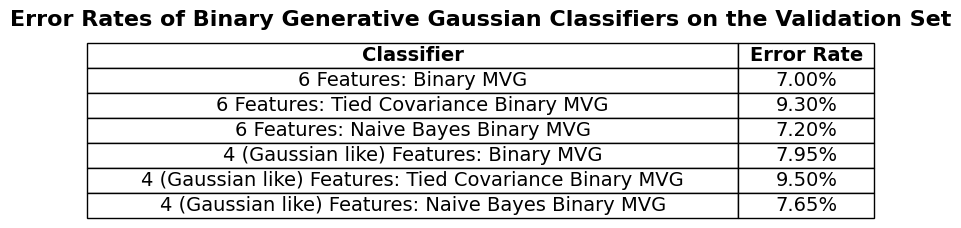

In [109]:
error_rates = [
    ("6 Features: Binary MVG", error_rate_bin_MVG), 
    ("6 Features: Tied Covariance Binary MVG", error_rate_bin_TiedCov),
    ("6 Features: Naive Bayes Binary MVG", error_rate_bin_NB),
    ("4 (Gaussian like) Features: Binary MVG", error_rate_bin_MVG_4f), 
    ("4 (Gaussian like) Features: Tied Covariance Binary MVG", error_rate_bin_TiedCov_4f),
    ("4 (Gaussian like) Features: Naive Bayes Binary MVG", error_rate_bin_NB_4f)
]

fig, ax = plt.subplots(figsize=(5, 2))
ax.axis('tight')
ax.axis('off')

table_data = [[name, f"{error:.2%}"] for name, error in error_rates]
table = ax.table(cellText=table_data, colLabels=["Classifier", "Error Rate"], loc="center")

#center text in the cells
for (i, j), cell in table.get_celld().items():
    if i == 0:
        cell.set_text_props(weight='bold')
    else:
        cell.set_text_props(ha='center', va='center')

table.auto_set_font_size(False)
table.set_fontsize(14)
table.auto_set_column_width([0, 1])
table.scale(1.5, 1.5)  # Adjust the scale for better visibility
plt.title("Error Rates of Binary Generative Gaussian Classifiers on the Validation Set", fontsize=16, weight='bold', pad=20)
plt.savefig("./models/ggm/error_rates_binary_6fvs4f.png", bbox_inches='tight', dpi=300) #save the figure with a resolution of 300 dpi
plt.show()

The conclusion is that the models trained on just the 4 "Most Gaussian like" features **are not better** than the first three original models! They actually perform a little worse! <br>
The reduction in accuracy suggests that the last two features might contribute some important information to the model. Even though they might not be perfectly modeled under Gaussian assumptions, they may still help in separating the classes.

Recall the variances computed for each separate feature: <br>
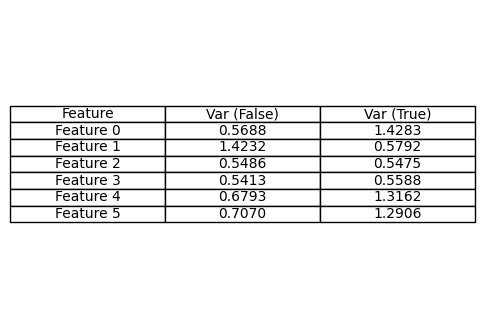 <br>

By looking at how the features are distributed, we can understand that features $0$, $1$ have similar means but different variances: <br>
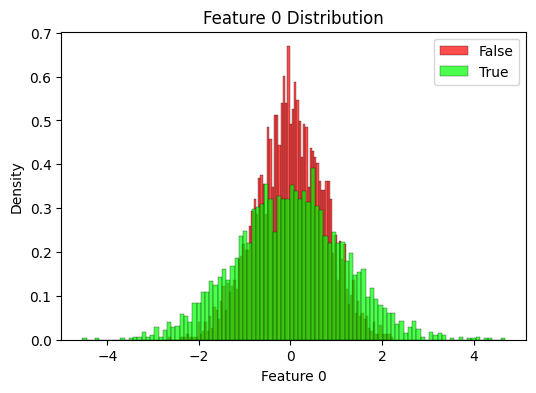  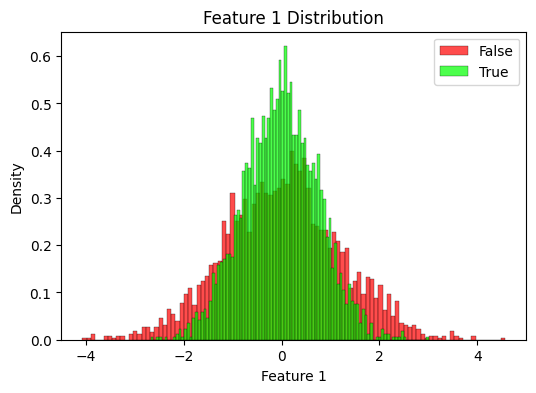 <br>
While features $2$, $3$ have similar variances but different means: <br>
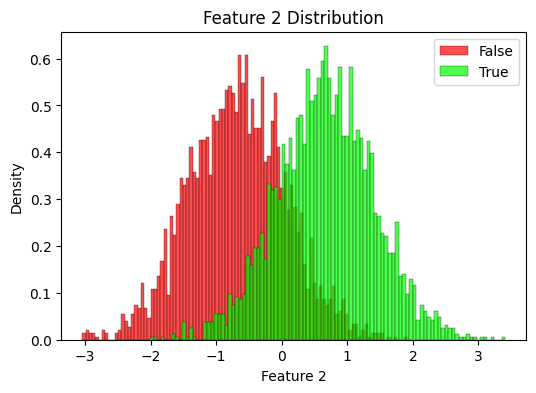 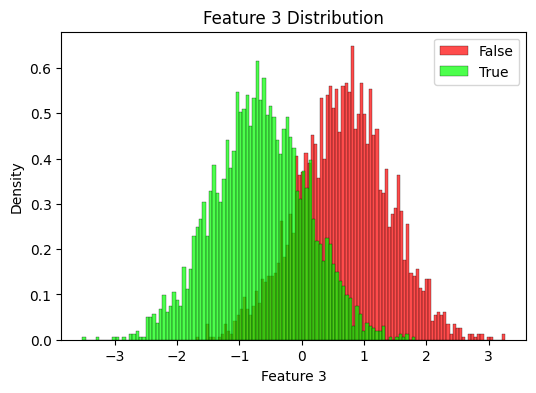 <br>
Also, the features show limited correlation for both classes: <br>
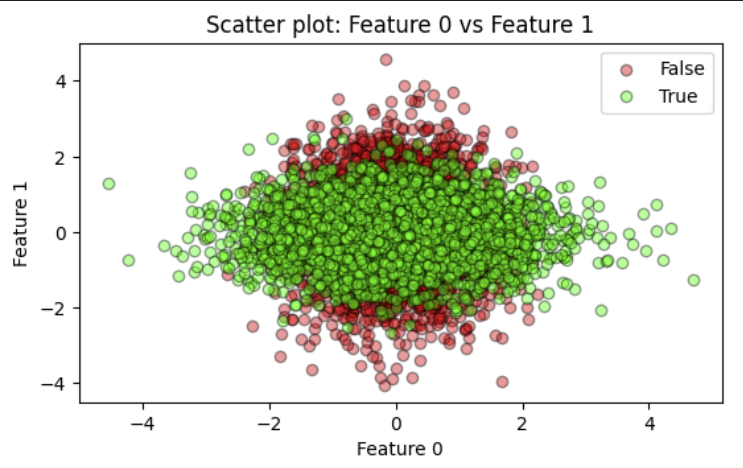 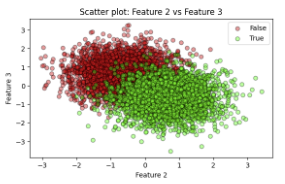 <br>

So the goal is to analyze and see **how these characteristics of the features distribution affect the performance of the different Gaussian Generative Models**:

### MVG Model applied first on just features 0, 1 and then on just features 2,3

#### Features $0$, $1$

In [110]:
#Apply the MVG classifier to just feature 0,1
DTR_01f = DTR[:2, :]
DVAL_01f = DVAL[:2, :]
print(f"DTR_01f shape: {DTR_01f.shape}\nDVAL_01f shape: {DVAL_01f.shape}")

ML_params_01f = MVG.computeParams_ML(DTR_01f, LTR)

S_LogLikelihoods_MVG_01f = MVG.scoreMatrix_Pdf_GAU(DVAL_01f, ML_params_01f, useLog=True)
print(f"S_LogLikelihoods_MVG_01f shape, computed from the Validation Set: {S_LogLikelihoods_MVG_01f.shape}")

llr_MVG_01f = S_LogLikelihoods_MVG_01f[1, :] - S_LogLikelihoods_MVG_01f[0, :]
print(f"llr Shape: {llr_MVG_01f.shape}")

#Classification rule: assign samples whose llr_MVG >= 0 to class 1 and samples whose llr_MVG < 0 to class 0
PVAL_bin_MVG_01f = np.where(llr_MVG_01f >= 0, 1, 0) #assign samples whose llr_MVG >= 0 to class 1 and samples whose llr_MVG < 0 to class 0
print(f"Predictions shape: {PVAL_bin_MVG_01f.shape}")
print(f"First 10 Predictions: {PVAL_bin_MVG_01f[:10]}")


#Error rate
error_count_bin_MVG_01f = np.count_nonzero(PVAL_bin_MVG_01f != LVAL)
print(f"Number of wrong predictions: {error_count_bin_MVG_01f}")
error_rate_bin_MVG_01f = np.mean(PVAL_bin_MVG_01f != LVAL)
print(f"Error Rate: {error_rate_bin_MVG_01f:.2%}")




DTR_01f shape: (2, 4000)
DVAL_01f shape: (2, 2000)
S_LogLikelihoods_MVG_01f shape, computed from the Validation Set: (2, 2000)
llr Shape: (2000,)
Predictions shape: (2000,)
First 10 Predictions: [1 0 1 1 0 1 0 1 0 0]
Number of wrong predictions: 730
Error Rate: 36.50%


#### Features $2$, $3$

In [111]:
# Apply the MVG classifier to just feature 2,3
DTR_23f = DTR[2:4, :]
DVAL_23f = DVAL[2:4, :]
print(f"DTR_23f shape: {DTR_23f.shape}\nDVAL_23f shape: {DVAL_23f.shape}")

ML_params_23f = MVG.computeParams_ML(DTR_23f, LTR)

S_LogLikelihoods_MVG_23f = MVG.scoreMatrix_Pdf_GAU(DVAL_23f, ML_params_23f, useLog=True)
print(f"S_LogLikelihoods_MVG_23f shape, computed from the Validation Set: {S_LogLikelihoods_MVG_23f.shape}")

llr_MVG_23f = S_LogLikelihoods_MVG_23f[1, :] - S_LogLikelihoods_MVG_23f[0, :]
print(f"llr Shape: {llr_MVG_23f.shape}")

# Classification rule
PVAL_bin_MVG_23f = np.where(llr_MVG_23f >= 0, 1, 0)
print(f"Predictions shape: {PVAL_bin_MVG_23f.shape}")
print(f"First 10 Predictions: {PVAL_bin_MVG_23f[:10]}")

# Error rate
error_count_bin_MVG_23f = np.count_nonzero(PVAL_bin_MVG_23f != LVAL)
print(f"Number of wrong predictions: {error_count_bin_MVG_23f}")
error_rate_bin_MVG_23f = np.mean(PVAL_bin_MVG_23f != LVAL)
print(f"Error Rate: {error_rate_bin_MVG_23f:.2%}")


DTR_23f shape: (2, 4000)
DVAL_23f shape: (2, 2000)
S_LogLikelihoods_MVG_23f shape, computed from the Validation Set: (2, 2000)
llr Shape: (2000,)
Predictions shape: (2000,)
First 10 Predictions: [0 0 1 0 0 1 0 0 0 0]
Number of wrong predictions: 189
Error Rate: 9.45%


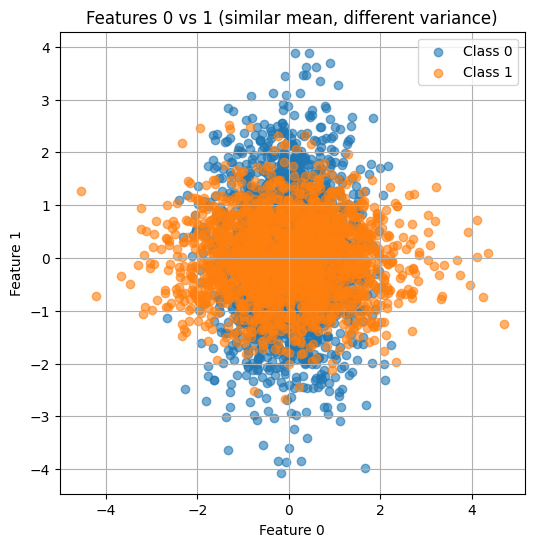

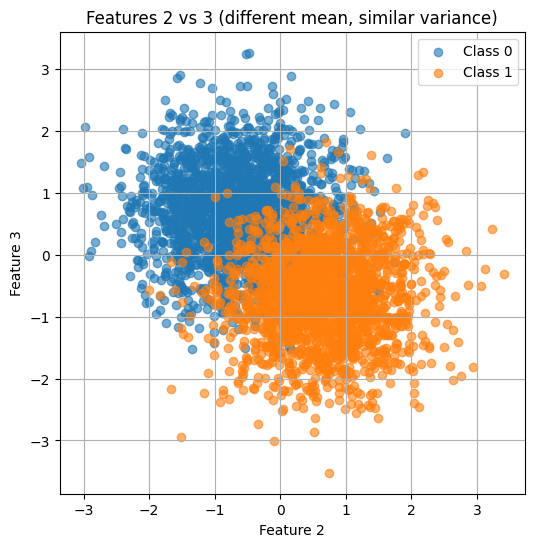

In [112]:
def plot_features(DTR, LTR, f1, f2, title):
    plt.figure(figsize=(6, 6))
    for label in [0, 1]:
        idx = (LTR == label)
        plt.scatter(DTR[f1, idx], DTR[f2, idx], label=f"Class {label}", alpha=0.6)
    plt.xlabel(f"Feature {f1}")
    plt.ylabel(f"Feature {f2}")
    plt.title(title)
    plt.legend()
    plt.grid(True)
    plt.show()

# Plot feature 0 and 1
plot_features(DTR, LTR, 0, 1, "Features 0 vs 1 (similar mean, different variance)")

# Plot feature 2 and 3
plot_features(DTR, LTR, 2, 3, "Features 2 vs 3 (different mean, similar variance)")

**Results**:
- The Classifier performs relatively well on features $2$, $3$ alone, despite the Error Rate being $\approx$ 2.5% higher than the one computed for the 6 features MVG Classifier and $\approx$ 1.5% higher than the one computed for the 4 more "Gaussian-like" features MVG Classifier. <br>
- The Classifier does not perform well in features $0$, $1$ alone, achieving an Error Rate of 36.5%, thus approx every 1 out of 3 predictions is *wrong*. 

**Explanation of the results**: <br>
Recall that the log-density for a MVG distribution, calculate as a result of the function `MVG.scoreMatrix_Pdf_GAU(...)` , is expressed, for a sample $x_t$, as:
$$
\log \mathcal{N}(x_t \mid \mu, \Sigma) = -\frac{D}{2} \log(2\pi) - \frac{1}{2} \log |\Sigma| - \frac{1}{2} (x_t - \mu)^T \Sigma^{-1} (x_t - \mu)
$$
Thus the $\text{llr}(x_t)$ can be rewritten as:
$$
\begin{align*}
\text{llr}(x_t) 
&= \log \frac{f_{X|C}(x_t \mid C=1)}{f_{X|C}(x_t \mid C=0)} = \\
&= \Bigg[ 
  -\frac{D}{2} \log(2\pi) 
  - \frac{1}{2} \log \left| \Sigma_1^{\text{MLE}} \right| 
  - \frac{1}{2} (x_t - \mu_1^{\text{MLE}})^T \left( \Sigma_1^{\text{MLE}} \right)^{-1} (x_t - \mu_1^{\text{MLE}}) 
\Bigg] \\
&\quad - \Bigg[ 
  -\frac{D}{2} \log(2\pi) 
  - \frac{1}{2} \log \left| \Sigma_0^{\text{MLE}} \right| 
  - \frac{1}{2} (x_t - \mu_0^{\text{MLE}})^T \left( \Sigma_0^{\text{MLE}} \right)^{-1} (x_t - \mu_0^{\text{MLE}}) 
\Bigg]
\end{align*}
$$

We can now write all the constants into $K$ and concentrate on the **key part** of the formula, which is the difference of the *Mahalanobis distances* of sample $x_t$ wrt class $1$ and class $0$:
$$
\text{llr}(x_t) = K - \frac{1}{2} (x_t - \mu_1^{\text{MLE}})^T \left( \Sigma_1^{\text{MLE}} \right)^{-1} (x_t - \mu_1^{\text{MLE}}) \\ 
  + \frac{1}{2} (x_t - \mu_0^{\text{MLE}})^T \left( \Sigma_0^{\text{MLE}} \right)^{-1} (x_t - \mu_0^{\text{MLE}})
$$
This difference shows how a sample $x_t$ is **nearer**, in the senso of Mahalanobis distance, **to a class wrt the other**. <br>
If $\mu_1$ is pretty distant from $\mu_0$ we end up having one of the Mahalanobis distances (between the mean and $x_t$) which is much higher than the other. This means that overall, after computing the difference between the two distances and adding all the constants $K$, the $\text{llr}(x_t)$ will be either $ > > > 0$ or $< < < 0$ and so the classification rule which compares:
$$ 
\text{llr}(x_{t}) = \log \mathcal{N}(x_t | \mu_1^{MLE}, \Sigma_1^{MLE}) - \log \mathcal{N}(x_t | \mu_0^{MLE}, \Sigma_0^{MLE}) \gtrless \text{Threshold} = 0
$$
**will surely assign a precise class to $x_t$ without a sign of uncertainty.** <br>
On the other hand, if we have $\mu_1 \approx \mu_0$, the two Mahalanobis distances will be very similar, so the difference between the two distances will be **near zero.** This means the classification rule **will be much less confident, and the classifier will struggle to differentiate between the two classes.** Since the Mahalanobis distances are similar, the decision boundary becomes more sensitive to small variations in the input data, leading to more misclassifications and uncertainty in the prediction. Essentially, when the means are close together, we have $\text{llr}(x_t) \approx K$, so the classifier relies more on the **covariances** (because $K = - \frac{1}{2} \log |\Sigma_1^{\text{MLE}}| + \frac{1}{2} \log |\Sigma_0^{\text{MLE}}|$), which may not provide as strong a distinction between the classes, especially when the data points are near the decision boundary


### Tied Covariance MVG Model applied first on just features 0, 1 and then on just features 2,3

#### Features $0$, $1$

In [113]:
ML_params_01f = MVGTC.computeParams_ML_TiedCov(DTR_01f, LTR)
CTied_01f = ML_params_01f[0][1]                        #get the tied covariance matrix for all classes
print(f"Tied covariance matrix shape: {CTied_01f.shape}")
print(f"Tied covariance matrix:\n{CTied_01f}")

S_LogLikelihoods_TiedCov_01f = MVG.scoreMatrix_Pdf_GAU(DVAL_01f, ML_params_01f, useLog=True)
print(f"S_LogLikelihoods_TiedCov_01f shape, computed from the Validation Set: {S_LogLikelihoods_TiedCov_01f.shape}")

llr_TiedCov_01f = S_LogLikelihoods_TiedCov_01f[1, :] - S_LogLikelihoods_TiedCov_01f[0, :]
print(f"llr Shape: {llr_TiedCov_01f.shape}")

#Classification rule: assign samples whose llr_MVG >= 0 to class 1 and samples whose llr_MVG < 0 to class 0
PVAL_bin_TiedCov_01f = np.where(llr_TiedCov_01f >= 0, 1, 0) #assign samples whose llr_MVG >= 0 to class 1 and samples whose llr_MVG < 0 to class 0
print(f"Predictions shape: {PVAL_bin_TiedCov_01f.shape}")
print(f"First 10 Predictions: {PVAL_bin_TiedCov_01f[:10]}")

error_count_bin_TiedCov_01f = np.count_nonzero(PVAL_bin_TiedCov_01f != LVAL)
print(f"Number of wrong predictions: {error_count_bin_TiedCov_01f}")
error_rate_bin_TiedCov_01f = np.mean(PVAL_bin_TiedCov_01f != LVAL)
print(f"Error Rate: {error_rate_bin_TiedCov_01f:.2%}")



Tied covariance matrix shape: (2, 2)
Tied covariance matrix:
[[ 1.02357476 -0.00734384]
 [-0.00734384  1.00151098]]
S_LogLikelihoods_TiedCov_01f shape, computed from the Validation Set: (2, 2000)
llr Shape: (2000,)
Predictions shape: (2000,)
First 10 Predictions: [0 0 1 0 0 1 0 1 1 1]
Number of wrong predictions: 989
Error Rate: 49.45%


#### Features $2$, $3$

In [114]:
ML_params_23f = MVGTC.computeParams_ML_TiedCov(DTR_23f, LTR)
CTied_23f = ML_params_23f[0][1]                        #get the tied covariance matrix for all classes
print(f"Tied covariance matrix shape: {CTied_23f.shape}")
print(f"Tied covariance matrix:\n{CTied_23f}")

S_LogLikelihoods_TiedCov_23f = MVG.scoreMatrix_Pdf_GAU(DVAL_23f, ML_params_23f, useLog=True)
print(f"S_LogLikelihoods_TiedCov_23f shape, computed from the Validation Set: {S_LogLikelihoods_TiedCov_23f.shape}")

llr_TiedCov_23f = S_LogLikelihoods_TiedCov_23f[1, :] - S_LogLikelihoods_TiedCov_23f[0, :]
print(f"llr Shape: {llr_TiedCov_23f.shape}")

#Classification rule: assign samples whose llr_MVG >= 0 to class 1 and samples whose llr_MVG < 0 to class 0
PVAL_bin_TiedCov_23f = np.where(llr_TiedCov_23f >= 0, 1, 0) #assign samples whose llr_MVG >= 0 to class 1 and samples whose llr_MVG < 0 to class 0
print(f"Predictions shape: {PVAL_bin_TiedCov_23f.shape}")
print(f"First 10 Predictions: {PVAL_bin_TiedCov_23f[:10]}")

error_count_bin_TiedCov_23f = np.count_nonzero(PVAL_bin_TiedCov_23f != LVAL)
print(f"Number of wrong predictions: {error_count_bin_TiedCov_23f}")
error_rate_bin_TiedCov_23f = np.mean(PVAL_bin_TiedCov_23f != LVAL)
print(f"Error Rate: {error_rate_bin_TiedCov_23f:.2%}")

Tied covariance matrix shape: (2, 2)
Tied covariance matrix:
[[0.56002077 0.01292037]
 [0.01292037 0.56109619]]
S_LogLikelihoods_TiedCov_23f shape, computed from the Validation Set: (2, 2000)
llr Shape: (2000,)
Predictions shape: (2000,)
First 10 Predictions: [0 0 1 0 0 1 0 0 0 0]
Number of wrong predictions: 188
Error Rate: 9.40%


**Results**:
- The Classifier performs relatively well on features $2$, $3$ alone, achieving an Error Rate comparable and pretty similar to the one computed for the 6 features MVG Classifier and to the one computed for the 4 more "Gaussian-like" features MVG Classifier. <br>
- The Classifier does not perform well in features $0$, $1$ alone, achieving an Error Rate of 49.45%, so approx. half of the predictions (989 out of 2000) are *wrong*.

**Explanation of the results**: <br>
In the Tied Covariance model, the $\text{llr}(x_t)$ which defines the dicision surface, simplifies into a linear function in $x_t$, so the separation line between classes is **linear** instead of quadratic:
$$
\text{llr}(x_t) = x_t^T b + c
$$
where:
$$
\begin{align*}
b &= \Lambda (\mu_1 - \mu_0) = \Sigma^{-1} (\mu_1 - \mu_0) \\
c &= -\frac{1}{2} \left( \mu_1^T \Lambda \mu_1 - \mu_0^T \Lambda \mu_0 \right) = -\frac{1}{2} \left( \mu_1^T \Sigma^{-1} \mu_1 - \mu_0^T \Sigma^{-1} \mu_0 \right)
\end{align*}
$$
From the equazion of the decision surface we can see that also this model performs better when features have more **different means**, since the direction of vector $b$, **which defines the orientation of the decision boundary**, is higly dependent on the difference between the means. <br>
If the means are very close, i.e. $\mu_1 \approx \mu_0$, then $b \approx 0$, so the resulting decision boundary becomes poorly defined, almost "flat", making it difficult to correctly separate the two classes. Moreover, the bias term $c$ also becomes less meaningful when the two means are close, because the quadratic terms $\mu_1^T \Sigma^{-1} \mu_1$ and $\mu_0^T \Sigma^{-1} \mu_0$ become very similar, leading to a small difference between them. <br>
This again confirms that, in both MVG and Tied MVG models, **the separability of the classes heavily depends on the distance between the means of the features**, more than on the variance structure, unless the variance is highly informative or strongly different

### Naive Bayes MVG Model applied first on just features 0, 1 and then on just features 2,3

#### Features $0$, $1$

In [115]:
ML_params_01f = MVGNB.computeParams_ML_NaiveBayesAssumption(DTR_01f, LTR)
print(f"Naive Bayes Parameters for 01f: {ML_params_01f}")


S_LogLikelihoods_NB_01f = MVGNB.scoreMatrix_Pdf_GAU(DVAL_01f, ML_params_01f, useLog=True)
print(f"S_LogLikelihoods_NB_01f shape, computed from the Validation Set: {S_LogLikelihoods_NB_01f.shape}")


llr_NB_01f = S_LogLikelihoods_NB_01f[1, :] - S_LogLikelihoods_NB_01f[0, :]
print(f"llr Shape: {llr_NB_01f.shape}")

#Classification rule: assign samples whose llr_MVG >= 0 to class 1 and samples whose llr_MVG < 0 to class 0
PVAL_bin_NB_01f = np.where(llr_NB_01f >= 0, 1, 0) #assign samples whose llr_MVG >= 0 to class 1 and samples whose llr_MVG < 0 to class 0
print(f"Predictions shape: {PVAL_bin_NB_01f.shape}")
print(f"First 10 Predictions: {PVAL_bin_NB_01f[:10]}")

error_count_bin_NB_01f = np.count_nonzero(PVAL_bin_NB_01f != LVAL)
print(f"Number of wrong predictions: {error_count_bin_NB_01f}")
error_rate_bin_NB_01f = np.mean(PVAL_bin_NB_01f != LVAL)
print(f"Error Rate: {error_rate_bin_NB_01f:.2%}")




Naive Bayes Parameters for 01f: [(array([[-0.00822607],
       [ 0.01103328]]), array([[0.60015048, 0.        ],
       [0.        , 1.44961338]])), (array([[-0.00640784],
       [-0.01442804]]), array([[1.44615303, 0.        ],
       [0.        , 0.5543039 ]]))]
S_LogLikelihoods_NB_01f shape, computed from the Validation Set: (2, 2000)
llr Shape: (2000,)
Predictions shape: (2000,)
First 10 Predictions: [1 0 1 1 0 1 0 1 0 0]
Number of wrong predictions: 726
Error Rate: 36.30%


#### Features $2$, $3$

In [116]:
ML_params_23f = MVGNB.computeParams_ML_NaiveBayesAssumption(DTR_23f, LTR)
print(f"Naive Bayes Parameters for 23f: {ML_params_23f}")

S_LogLikelihoods_NB_23f = MVGNB.scoreMatrix_Pdf_GAU(DVAL_23f, ML_params_23f, useLog=True)
print(f"S_LogLikelihoods_NB_23f shape, computed from the Validation Set: {S_LogLikelihoods_NB_23f.shape}")

llr_NB_23f = S_LogLikelihoods_NB_23f[1, :] - S_LogLikelihoods_NB_23f[0, :]
print(f"llr Shape: {llr_NB_23f.shape}")

#Classification rule: assign samples whose llr_MVG >= 0 to class 1 and samples whose llr_MVG < 0 to class 0
PVAL_bin_NB_23f = np.where(llr_NB_23f >= 0, 1, 0) #assign samples whose llr_MVG >= 0 to class 1 and samples whose llr_MVG < 0 to class 0
print(f"Predictions shape: {PVAL_bin_NB_23f.shape}")
print(f"First 10 Predictions: {PVAL_bin_NB_23f[:10]}")

error_count_bin_NB_23f = np.count_nonzero(PVAL_bin_NB_23f != LVAL)
print(f"Number of wrong predictions: {error_count_bin_NB_23f}")
error_rate_bin_NB_23f = np.mean(PVAL_bin_NB_23f != LVAL)
print(f"Error Rate: {error_rate_bin_NB_23f:.2%}")

Naive Bayes Parameters for 23f: [(array([[-0.66765899],
       [ 0.68274212]]), array([[0.56394929, 0.        ],
       [0.        , 0.5469237 ]])), (array([[ 0.66074454],
       [-0.6633144 ]]), array([[0.5561001 , 0.        ],
       [0.        , 0.57524036]]))]
S_LogLikelihoods_NB_23f shape, computed from the Validation Set: (2, 2000)
llr Shape: (2000,)
Predictions shape: (2000,)
First 10 Predictions: [0 0 1 0 0 1 0 0 0 0]
Number of wrong predictions: 189
Error Rate: 9.45%


**Results**:
- The Classifier performs relatively well on features $2$, $3$ alone, achieving an Error Rate slightly higher than the one computed for the 6 features MVG Classifier and the one computed for the 4 more "Gaussian-like" features MVG Classifier. <br>
- The Classifier does not perform well in features $0$, $1$ alone, achieving an Error Rate of 36.30%, so approx. one third of the predictions are *wrong*.

**Explanation of the results**: <br>
This model behaves exactly the same the MVG and the Tied Covariance MVG Classifiers. In facts, all the calculations are the same as what we've done with the MVG Classifier, the only thing that changes are the class Covariance Matrices $\Sigma_c$ which are now diagonal according to:
$$
\Sigma_c^{MLE, \space Naive Bayes} = \text{diag}(\Sigma_c^{MLE}) = \text{diag} \left[ \frac{1}{N_c} \sum_i (x_{c,i} - \mu_c^{MLE})(x_{c,i} - \mu_c^{MLE})^T \right]
$$
Regarding the $\text{llr}(x_t)$, the result is the same as with the MVG Classifier:
$$
\text{llr}(x_t) = K - \frac{1}{2} (x_t - \mu_1^{\text{MLE}})^T \left( \Sigma_1^{\text{MLE, \space Naive Bayes}} \right)^{-1} (x_t - \mu_1^{\text{MLE}}) \\ 
  + \frac{1}{2} (x_t - \mu_0^{\text{MLE}})^T \left( \Sigma_0^{\text{MLE, \space Naive Bayes}} \right)^{-1} (x_t - \mu_0^{\text{MLE}})
$$
So again, if $\mu_1$ is very far from $\mu_0$, the difference between the two Mahalanobis distances will be higher and the model will perform well. <br>
Again, if $\mu_1 \approx \mu_0$, then e two Mahalanobis distances will be very similar, so the difference between the two distances will be **near zero.** This means the classification rule **will be much less confident, and the classifier will struggle to differentiate between the two classes.**

### 5. Effects of PCA applied with the Generative Gaussian Models

Now the aim is to analyze how PCA can affect the application of the three Gaussian Generative Models. <br>
So, PCA is applied with $m$ (i.e. the target dimensionality that we want to achieve) going from 6 to 2. Then the three Generative Gaussian Models are fitted and the results are compared.

In [121]:
from pca_functions import calculatePCA, applyPCA
from plot_functions import densityPlots_TR_VAL

In [122]:
DTR.shape, LTR.shape, DVAL.shape, LVAL.shape

((6, 4000), (4000,), (6, 2000), (2000,))

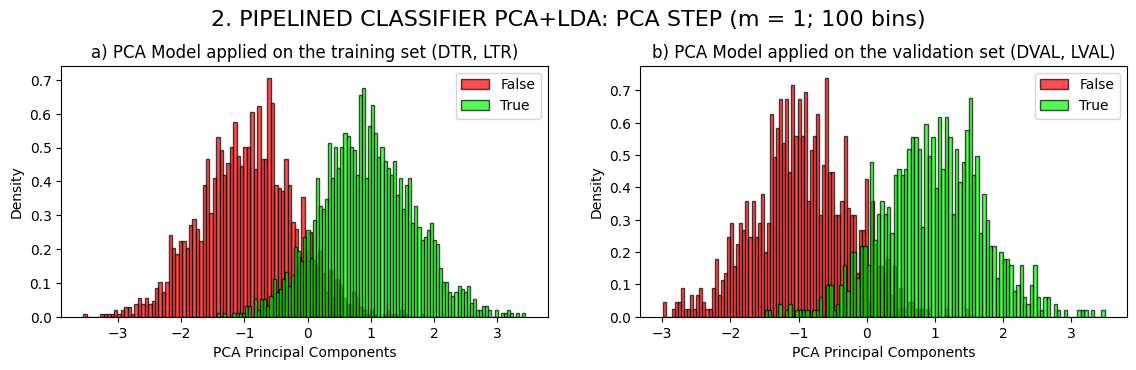

Error Rate MVG: 9.10%
Error Rate Tied Covariance MVG: 9.25%
Error Rate Naive Bayes MVG: 9.10%


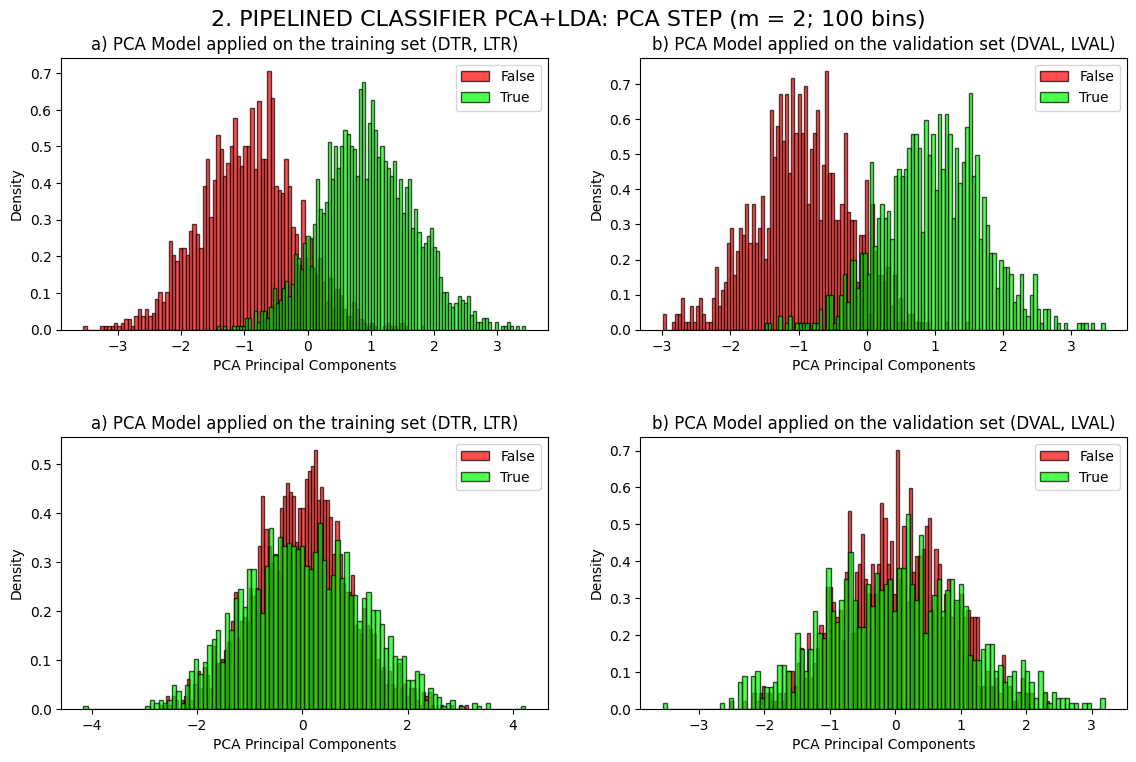

Error Rate MVG: 8.80%
Error Rate Tied Covariance MVG: 9.40%
Error Rate Naive Bayes MVG: 8.80%


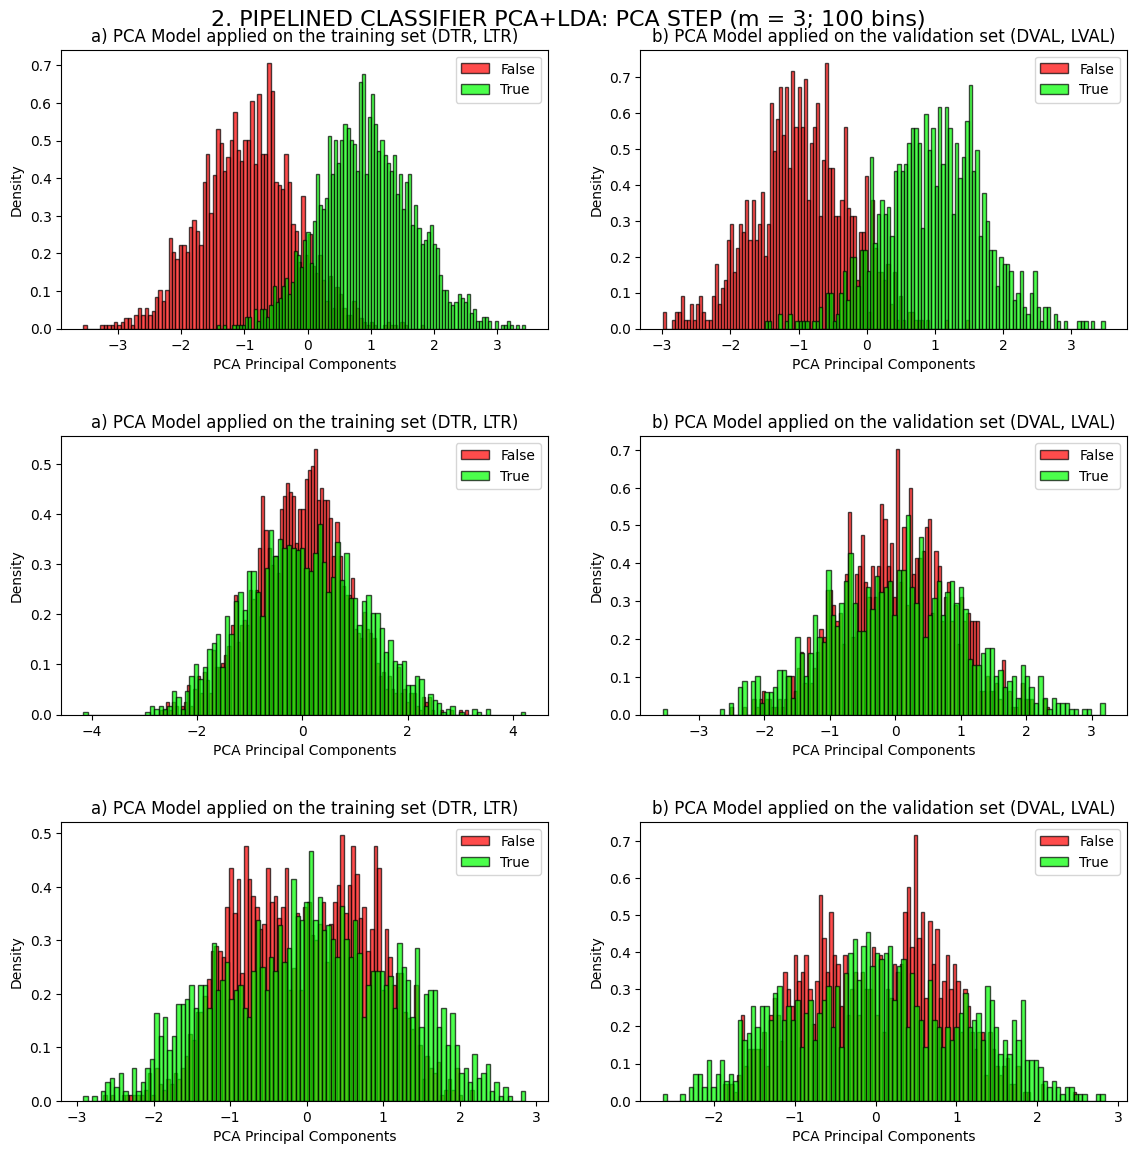

Error Rate MVG: 9.00%
Error Rate Tied Covariance MVG: 9.25%
Error Rate Naive Bayes MVG: 9.05%


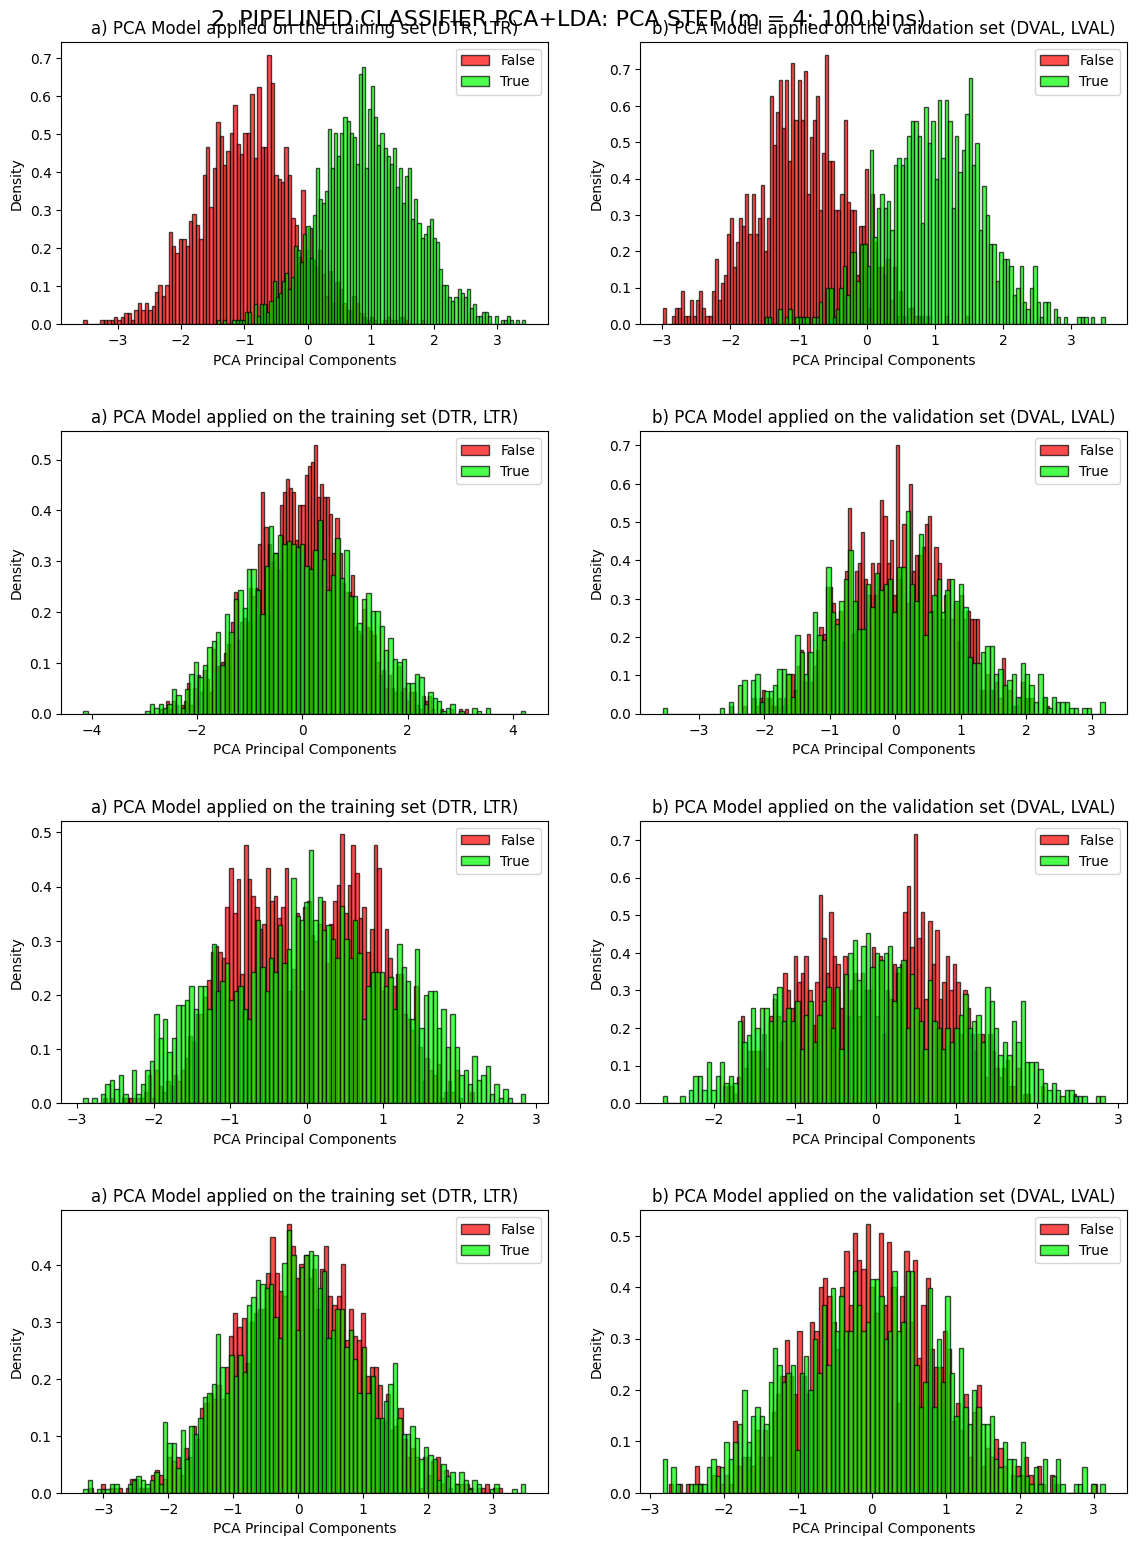

Error Rate MVG: 8.00%
Error Rate Tied Covariance MVG: 9.20%
Error Rate Naive Bayes MVG: 8.90%


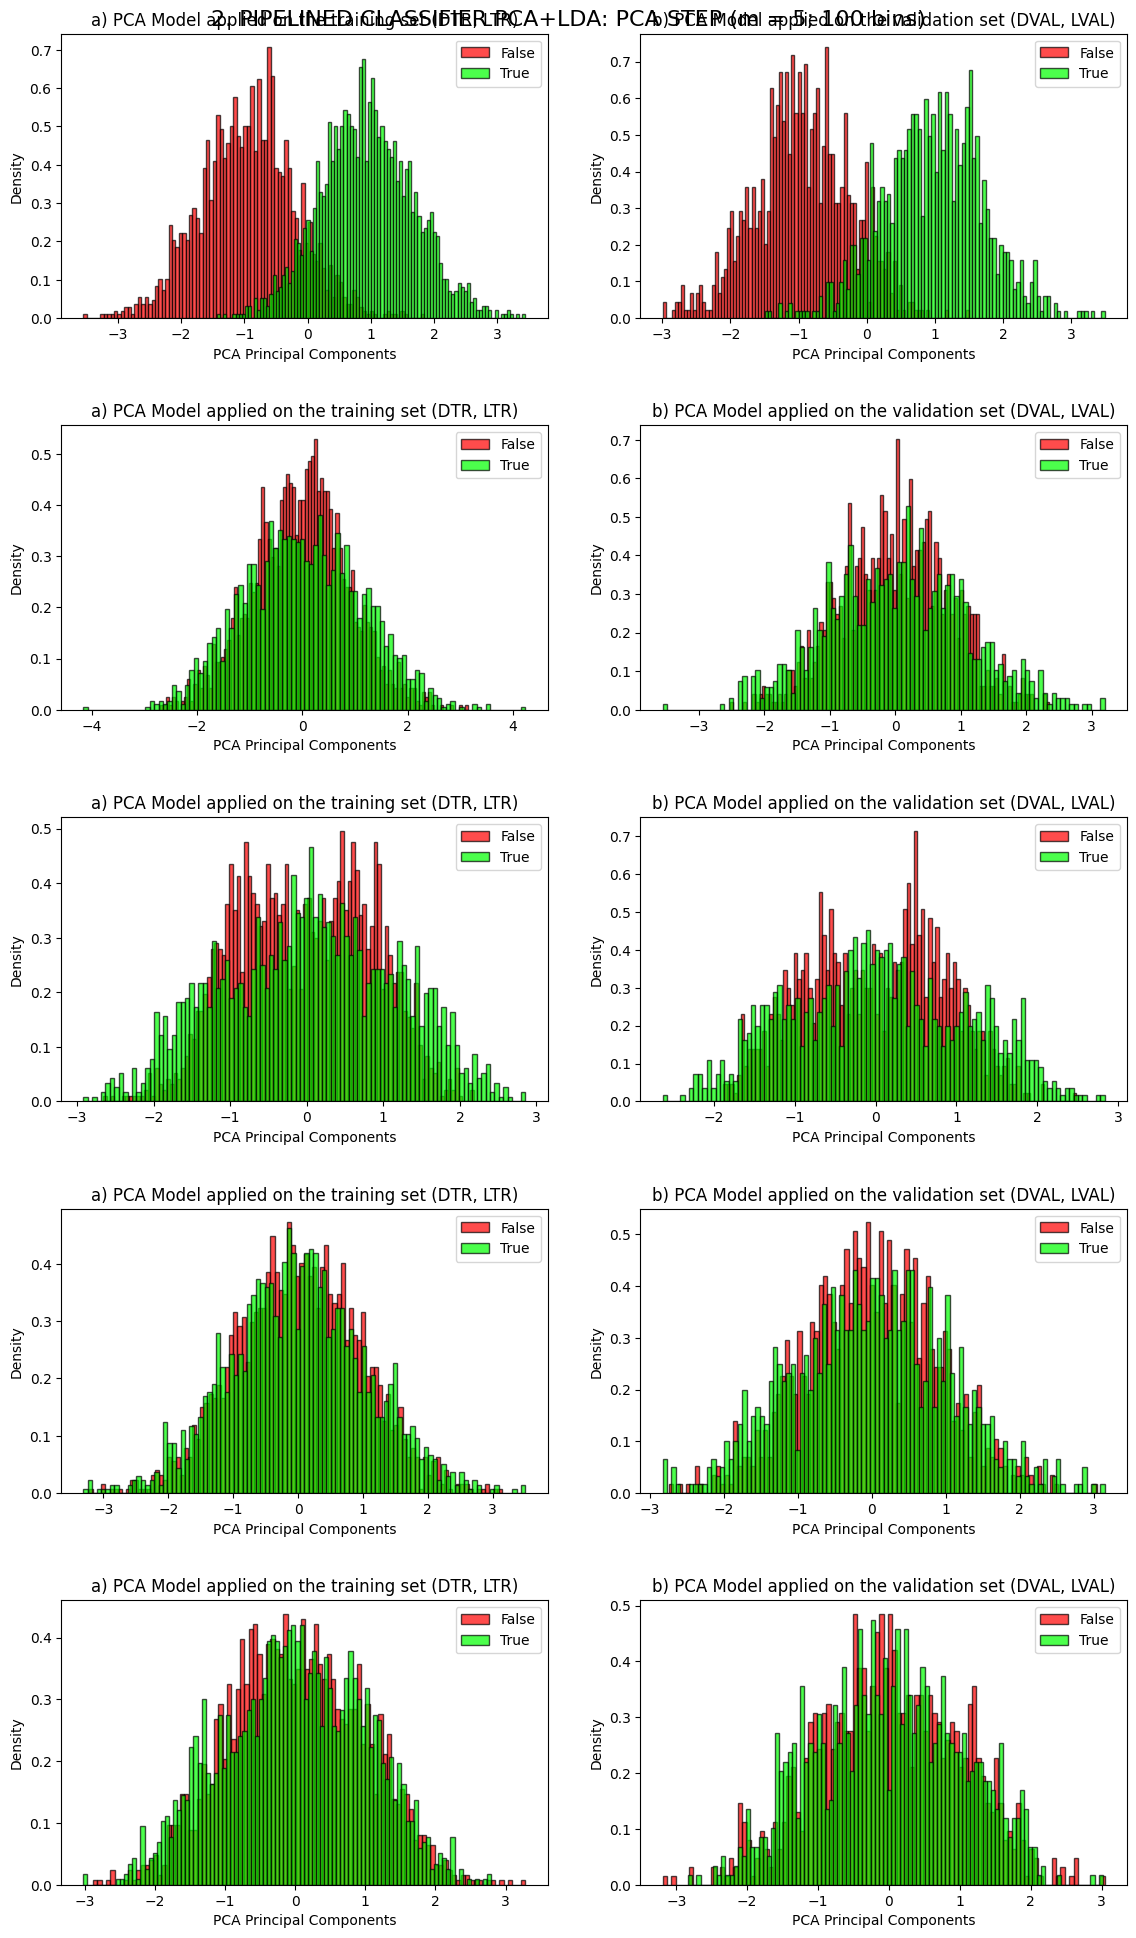

Error Rate MVG: 7.05%
Error Rate Tied Covariance MVG: 9.25%
Error Rate Naive Bayes MVG: 8.75%


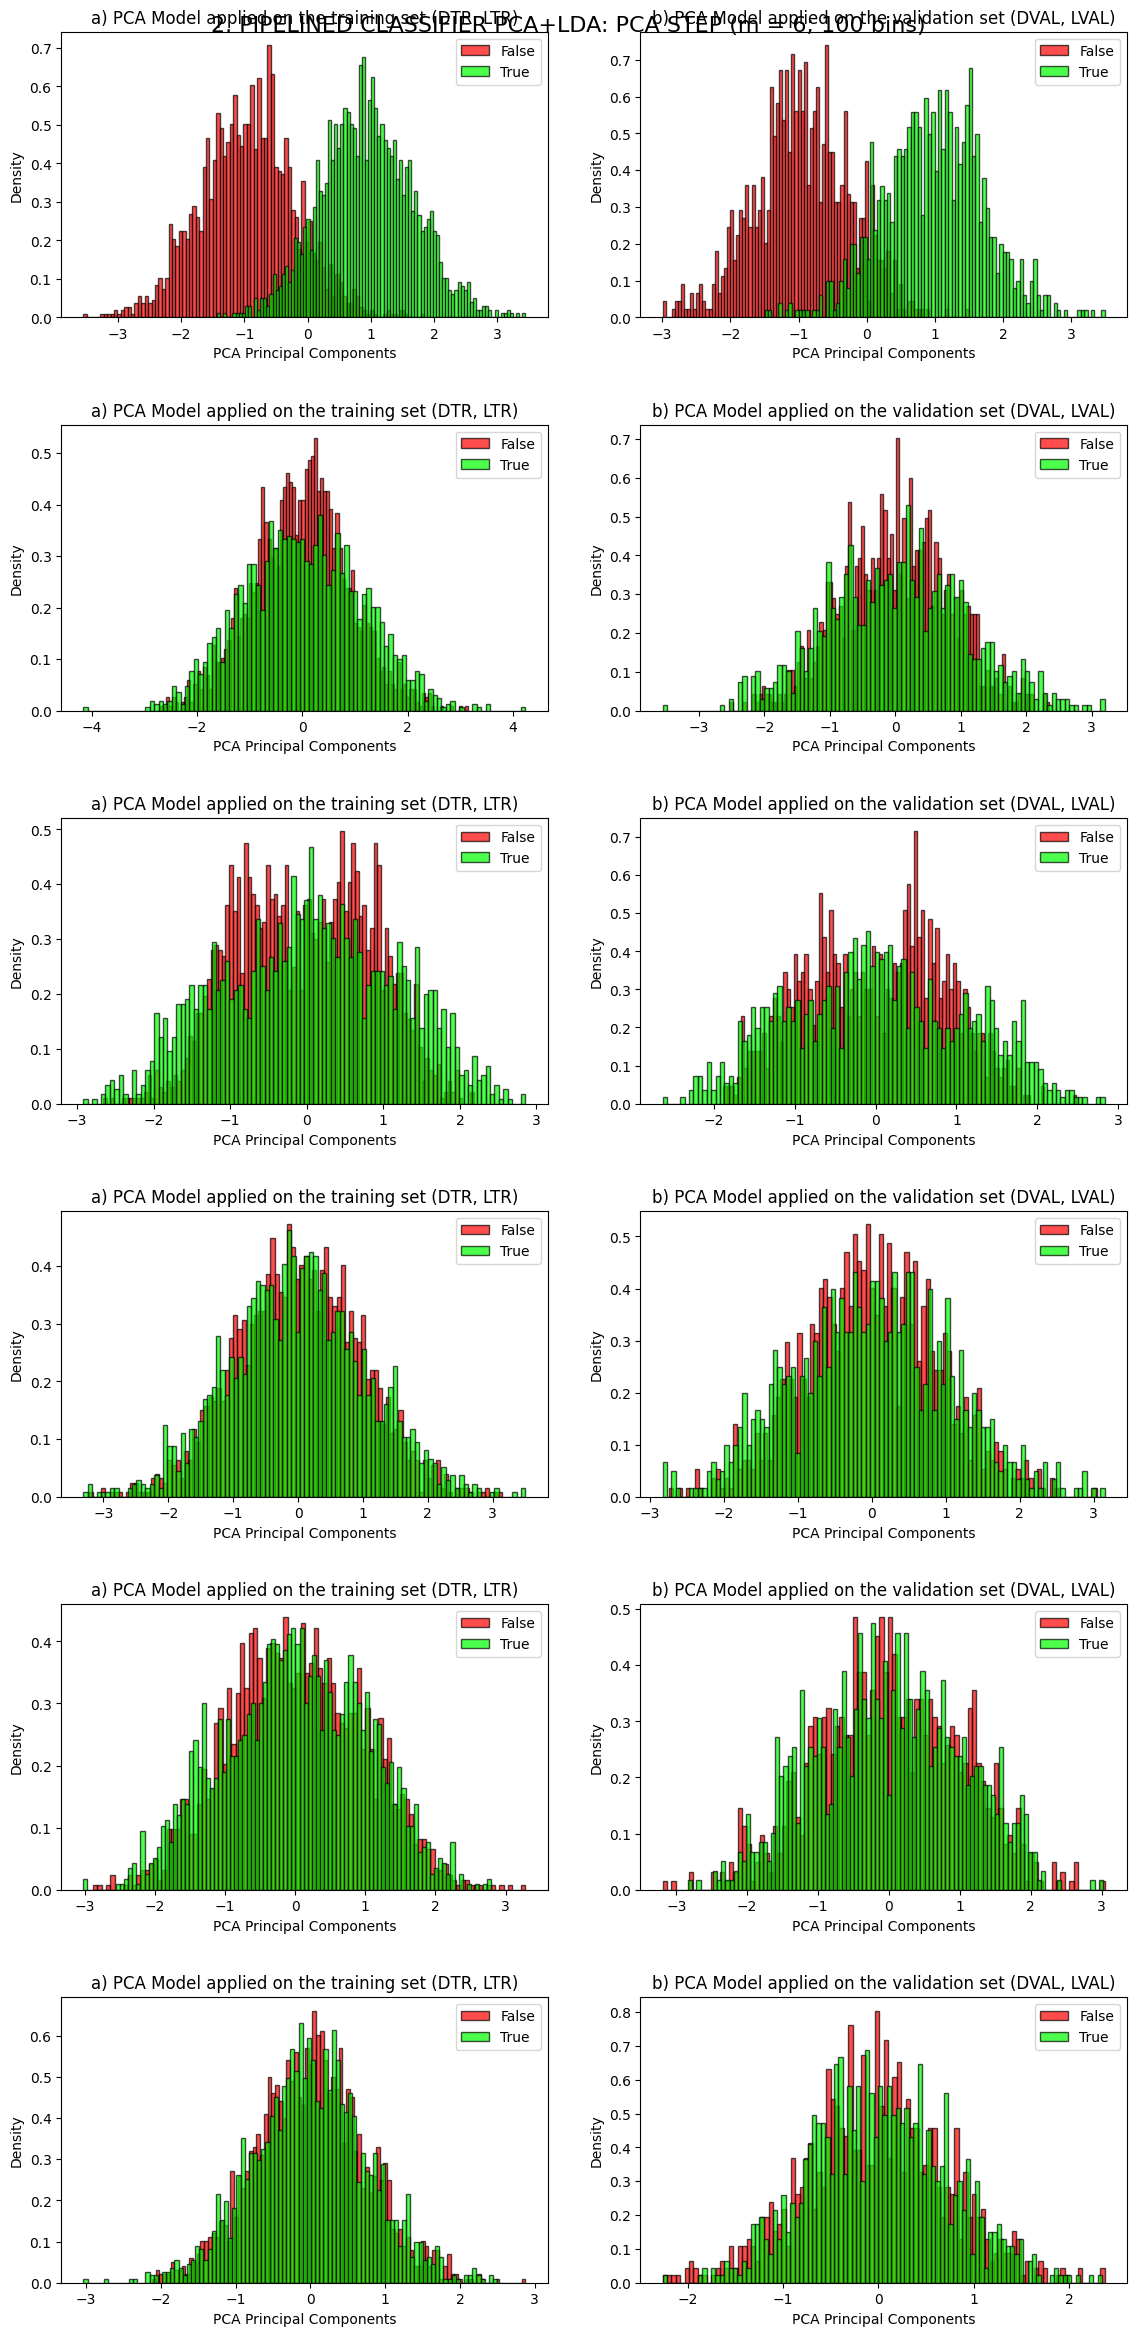

Error Rate MVG: 7.00%
Error Rate Tied Covariance MVG: 9.30%
Error Rate Naive Bayes MVG: 8.90%


In [134]:

labelColors = {0: "red", 1: "#00ff00"}
classLabels = {0: "False", 1: "True"}

errorRates = [] 
#index: m of PCA


for m in range(1, numFeatures+1):
    #Apply PCA with m 
    #Then fit the three ggm
    P_m = calculatePCA(DTR, m)
    DTR_m = applyPCA(DTR, P_m)
    DVAL_m = applyPCA(DVAL, P_m)
    
    densityPlots_TR_VAL(DTR_m, LTR, DVAL_m, LVAL, title1="a) PCA Model applied on the training set (DTR, LTR)", bins1=100, title2="b) PCA Model applied on the validation set (DVAL, LVAL)", bins2=100, title=f"2. PIPELINED CLASSIFIER PCA+LDA: PCA STEP (m = {m}; 100 bins)", xlabel = "PCA Principal Components", labelColors=labelColors, classLabels=classLabels, rows=m, cols=2)

    errorRates_m = {} #key: model name, value: error rate

    #1. MVG
    ML_params_m = MVG.computeParams_ML(DTR_m, LTR)
    S_LogLikelihoods_MVG_m = MVG.scoreMatrix_Pdf_GAU(DVAL_m, ML_params_m, useLog=True)
    llr_MVG_m = S_LogLikelihoods_MVG_m[1, :] - S_LogLikelihoods_MVG_m[0, :]
    PVAL_bin_MVG_m = np.where(llr_MVG_m >= 0, 1, 0) #assign samples whose llr_MVG >= 0 to class 2 and samples whose llr_MVG < 0 to class 1
    error_count_bin_MVG_m = np.count_nonzero(PVAL_bin_MVG_m != LVAL)
    error_rate_bin_MVG_m = np.mean(PVAL_bin_MVG_m != LVAL)

    errorRates_m["MVG"] = error_rate_bin_MVG_m
    print(f"Error Rate MVG: {error_rate_bin_MVG_m:.2%}")

    #2. Tied Covariance MVG
    ML_params_m = MVGTC.computeParams_ML_TiedCov(DTR_m, LTR)
    S_LogLikelihoods_MVGTC_m = MVGTC.scoreMatrix_Pdf_GAU(DVAL_m, ML_params_m, useLog=True)
    llr_MVGTC_m = S_LogLikelihoods_MVGTC_m[1, :] - S_LogLikelihoods_MVGTC_m[0, :]
    PVAL_bin_MVGTC_m = np.where(llr_MVGTC_m >= 0, 1, 0) #assign samples whose llr_MVGTC >= 0 to class 2 and samples whose llr_MVG < 0 to class 1
    error_count_bin_MVGTC_m = np.count_nonzero(PVAL_bin_MVGTC_m != LVAL)
    error_rate_bin_MVGTC_m = np.mean(PVAL_bin_MVGTC_m != LVAL)

    errorRates_m["Tied Covariance MVG"] = error_rate_bin_MVGTC_m
    print(f"Error Rate Tied Covariance MVG: {error_rate_bin_MVGTC_m:.2%}")

    #3. Naive Bayes MVG
    ML_params_m = MVGNB.computeParams_ML_NaiveBayesAssumption(DTR_m, LTR)
    S_LogLikelihoods_NB_m = MVGNB.scoreMatrix_Pdf_GAU(DVAL_m, ML_params_m, useLog=True)
    llr_NB_m = S_LogLikelihoods_NB_m[1, :] - S_LogLikelihoods_NB_m[0, :]
    PVAL_bin_NB_m = np.where(llr_NB_m >= 0, 1, 0) #assign samples whose llr_MVG >= 0 to class 2 and samples whose llr_MVG < 0 to class 1
    error_count_bin_NB_m = np.count_nonzero(PVAL_bin_NB_m != LVAL)
    error_rate_bin_NB_m = np.mean(PVAL_bin_NB_m != LVAL)

    errorRates_m["Naive Bayes MVG"] = error_rate_bin_NB_m
    print(f"Error Rate Naive Bayes MVG: {error_rate_bin_NB_m:.2%}")

    errorRates.append(errorRates_m)


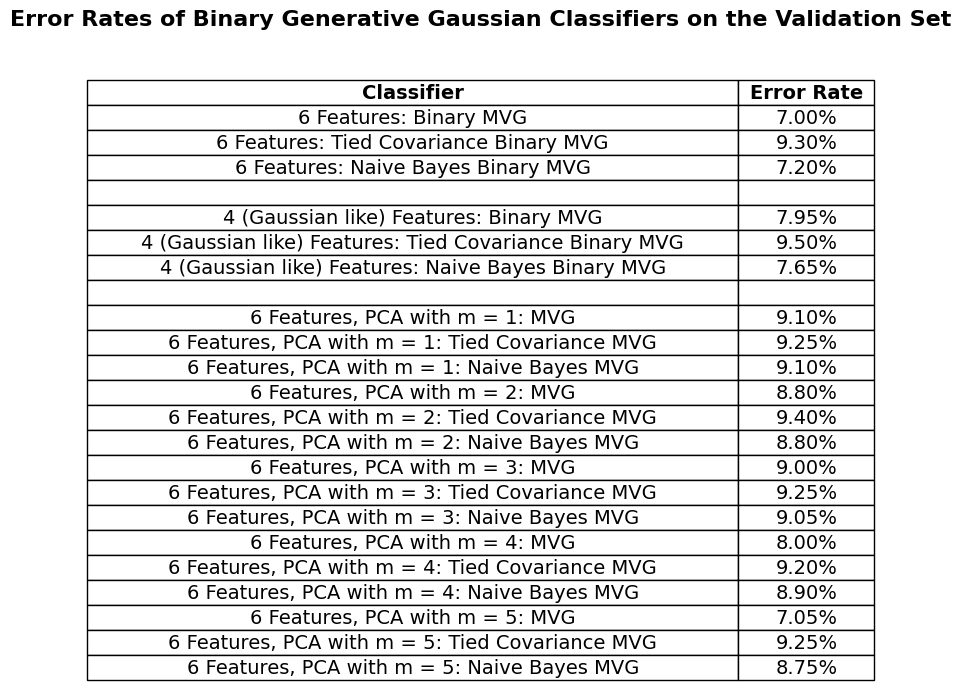

In [136]:
error_rates = [
    ("6 Features: Binary MVG", error_rate_bin_MVG), 
    ("6 Features: Tied Covariance Binary MVG", error_rate_bin_TiedCov),
    ("6 Features: Naive Bayes Binary MVG", error_rate_bin_NB),
    ("", ""),
    ("4 (Gaussian like) Features: Binary MVG", error_rate_bin_MVG_4f), 
    ("4 (Gaussian like) Features: Tied Covariance Binary MVG", error_rate_bin_TiedCov_4f),
    ("4 (Gaussian like) Features: Naive Bayes Binary MVG", error_rate_bin_NB_4f),
    ("", "")
]


#for each m, add the error rates to the list
for m in range(1, numFeatures):
    errorRates_m = errorRates[m-1]
    for model, errorRateModel in errorRates_m.items():
        error_rates.append((f"6 Features, PCA with m = {m}: {model}", errorRateModel))
    errorRates.append(("", ""))

fig, ax = plt.subplots(figsize=(5, 2))
ax.axis('tight')
ax.axis('off')

table_data = [[name, f"{error:.2%}"] if name != "" and error != "" else [None, None] for name, error in error_rates]
table = ax.table(cellText=table_data, colLabels=["Classifier", "Error Rate"], loc="center")

#center text in the cells
for (i, j), cell in table.get_celld().items():
    if i == 0:
        cell.set_text_props(weight='bold')
    else:
        cell.set_text_props(ha='center', va='center')

table.auto_set_font_size(False)
table.set_fontsize(14)
table.auto_set_column_width([0, 1])
table.scale(1.5, 1.5)  # Adjust the scale for better visibility
plt.title("Error Rates of Binary Generative Gaussian Classifiers on the Validation Set", fontsize=16, weight='bold', pad=200)
plt.savefig("./models/ggm/error_rates_all_ggm_also_PCA", bbox_inches='tight', dpi=300) #save the figure with a resolution of 300 dpi
plt.show()